# Lección 1.1 · El dogma central como sistema de información

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-01-biologia-molecular/1.1_dogma_central.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 1 — Biología molecular para bioinformáticos** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3 horas | Introductorio–intermedio | Módulo 0 (Python, numpy, Biopython) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Describir** el dogma central (replicación, transcripción, traducción) como un sistema que **guarda, copia y
   ejecuta** información, y reconocer sus excepciones (transcripción reversa, virus de ARN).
2. **Implementar** desde cero la transcripción y la traducción en Python, y verificarlas contra Biopython.
3. **Medir** la información de una secuencia en **bits**: capacidad máxima ($\log_2 4 = 2$ bits por base),
   **entropía de Shannon** y compresión.
4. **Calcular** cuánto "pesa" un genoma en bytes y comparar organismos.
5. **Explorar** con gráficos interactivos la entropía a lo largo del genoma real de SARS-CoV-2.
6. **Cuantificar** la robustez del código genético frente a mutaciones puntuales en el gen Spike real y compararla
   con miles de códigos genéticos alternativos generados al azar.

## 🗺️ Mapa de la clase

1. La célula como sistema de información: el dogma central
2. Replicación, transcripción y traducción, paso a paso (con dos animaciones)
3. ¿Cuánta información cabe en una base? Bits y tamaño de genomas
4. Entropía de Shannon: medir la sorpresa de una secuencia
5. 🧪 Experimento: la entropía a lo largo del genoma de SARS-CoV-2 (interactivo)
6. 🧪 Experimento: compresión, la información medida "a la fuerza bruta"
7. 🧪 Experimento: ¿qué tan robusto es el código genético? (gen Spike + un millón de dudas)
8. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import plotly.express as px
import plotly.graph_objects as go
try:
    import Bio
except ImportError:
    %pip install -q biopython
from Bio import SeqIO, Entrez
from Bio.Seq import Seq

Entorno listo ✔  |  Colab: False


## 1. La célula como sistema de información

Piense en una gran **biblioteca de planos** de una fábrica. En la bóveda se guardan los planos originales: nunca
salen de allí, se protegen y se copian con muchísimo cuidado cuando la fábrica se divide en dos. Cuando un taller
necesita construir una pieza, no se lleva el plano original: saca una **fotocopia de trabajo** de la página que le
interesa, la lleva al taller y allí una máquina lee la fotocopia y **ensambla la pieza**. La fotocopia se descarta
después de unas horas; el original sigue a salvo.

La célula funciona exactamente así:

| En la fábrica | En la célula | Proceso | Enzima / maquinaria |
|---|---|---|---|
| Planos originales en la bóveda | **ADN** en el núcleo (o nucleoide) | — | — |
| Copiar la bóveda completa antes de dividirse | ADN → ADN | **Replicación** | ADN polimerasa |
| Fotocopia de trabajo de una página | ADN → **ARN mensajero** | **Transcripción** | ARN polimerasa |
| La máquina que ensambla la pieza leyendo la fotocopia | ARNm → **proteína** | **Traducción** | Ribosoma + ARNt |
| La pieza terminada que hace el trabajo | **Proteína** (enzima, estructura, señal) | — | — |

Francis Crick lo formuló en 1958 y lo precisó en 1970 con una idea más fina de lo que suele recordarse: el dogma
central **no** dice "ADN → ARN → proteína" y nada más; dice que **una vez que la información ha pasado a una
proteína, no puede volver atrás** (no existe una "traducción reversa"). Otras transferencias sí existen:

* **Transcripción reversa (ARN → ADN):** la hacen los retrovirus como el VIH con la enzima *transcriptasa reversa*
  (y la usamos en el laboratorio para la RT-PCR).
* **Replicación de ARN (ARN → ARN):** la hacen virus de ARN como SARS-CoV-2, cuyo genoma **es** ARN y se copia con
  una ARN polimerasa dependiente de ARN (RdRp).

Para un bioinformático, lo más importante de esta tabla es que **todas estas moléculas son textos**: el ADN y el ARN
se escriben con 4 letras, y las proteínas con 20. Todo el curso consiste en leer, comparar y modelar esos textos.
Veamos el mapa completo:

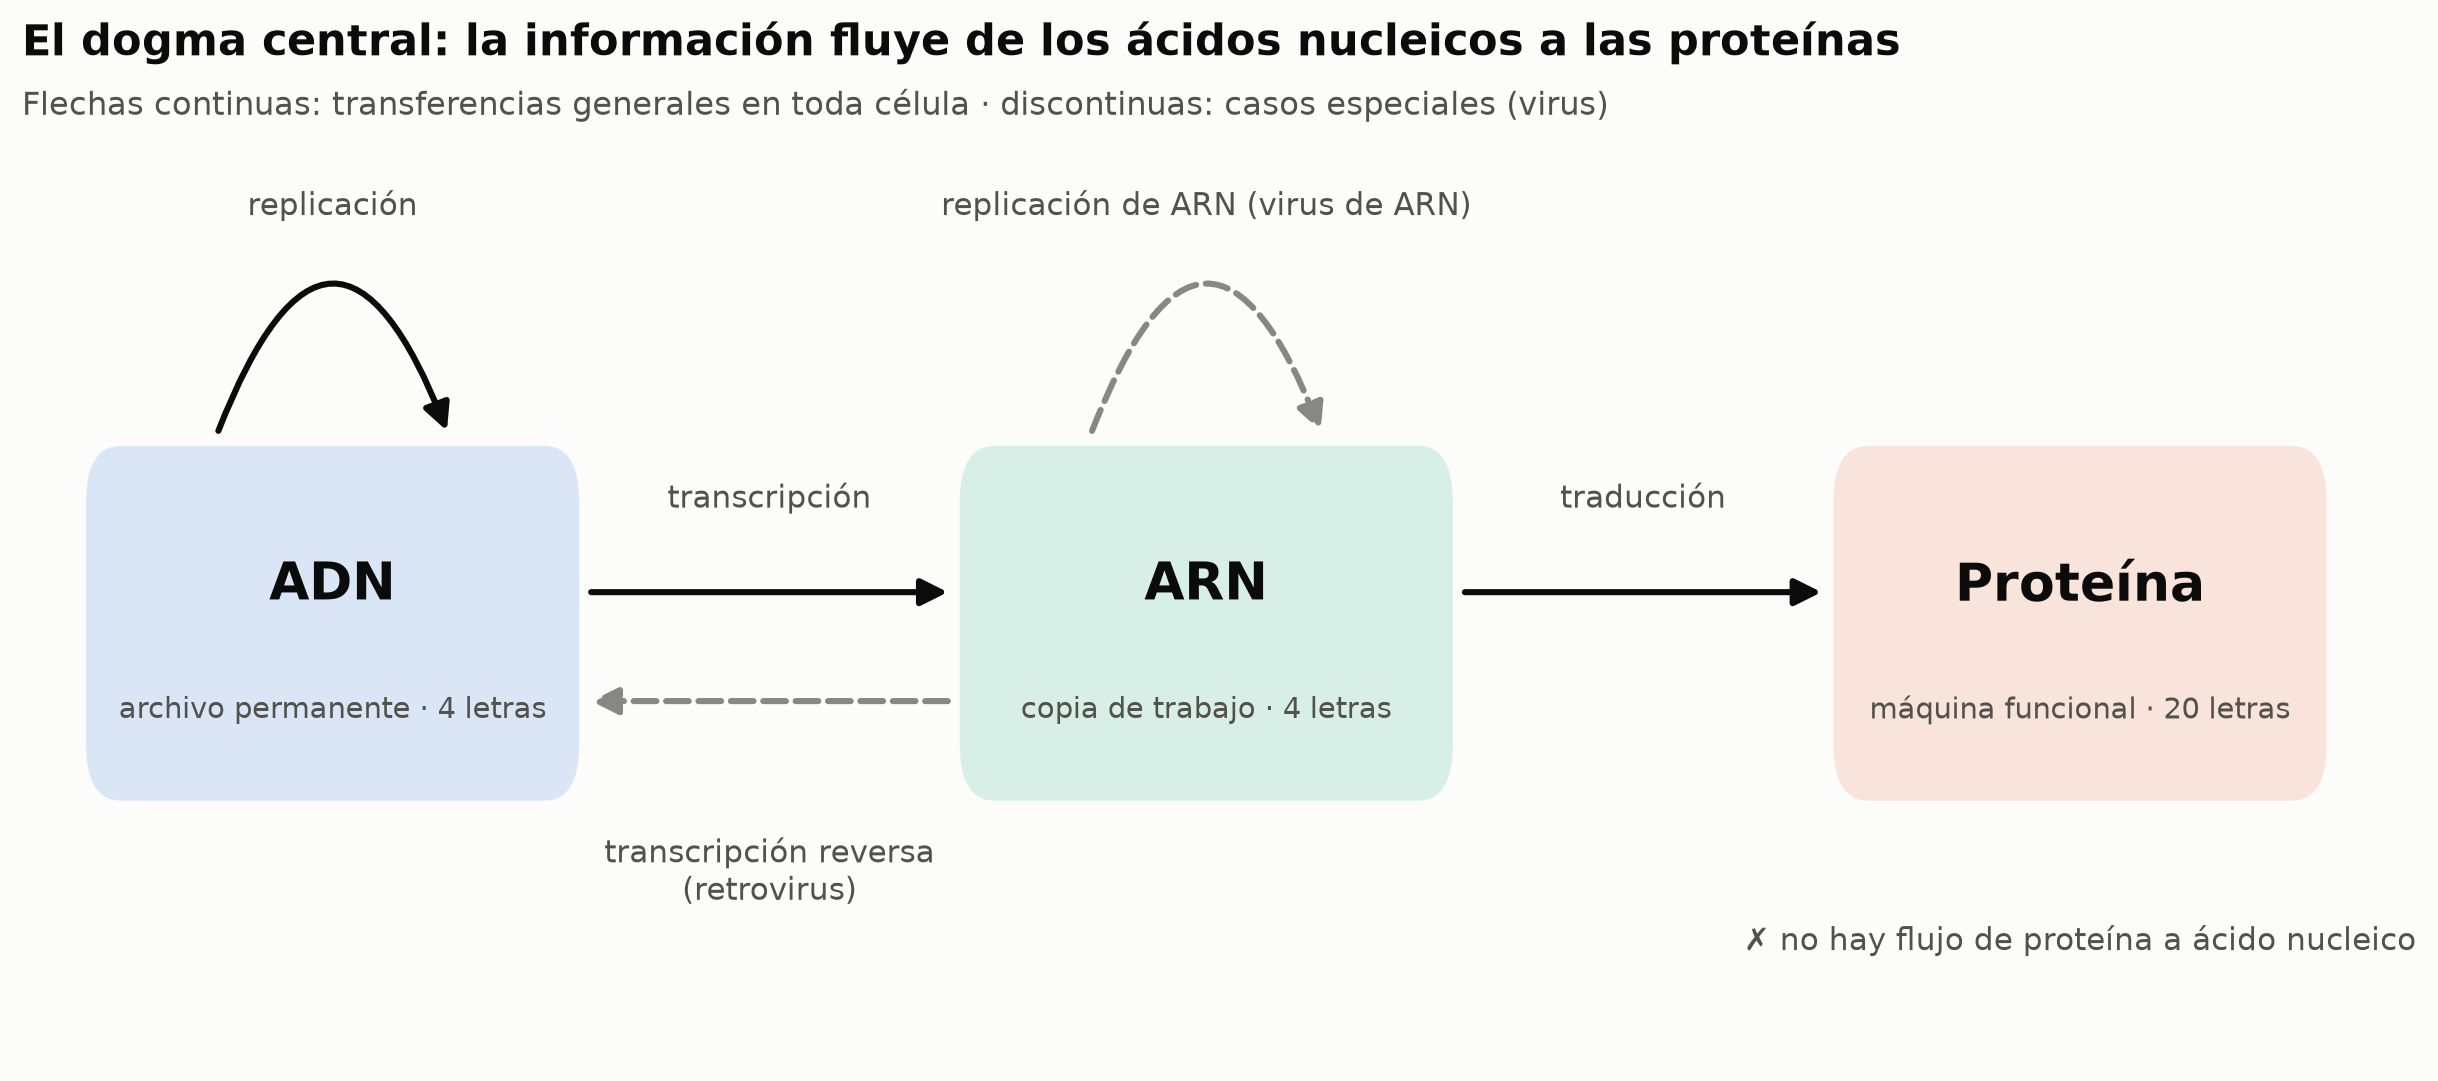

In [2]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def box(ax, xy, text, sub, color):
    x, y = xy
    ax.add_patch(FancyBboxPatch((x - 1.25, y - 0.55), 2.5, 1.1, boxstyle="round,pad=0.02,rounding_size=0.18",
                                fc=color, ec="none", alpha=0.16))
    ax.text(x, y + 0.12, text, ha="center", va="center", fontsize=17, fontweight="bold", color=ec.INK)
    ax.text(x, y - 0.28, sub, ha="center", va="center", fontsize=9.5, color=ec.INK_2)

def arrow(ax, p0, p1, label, color, rad=0.0, style="-|>", ls="-", lx=0, ly=0.28):
    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle=style, mutation_scale=18, color=color, lw=2,
                                 connectionstyle=f"arc3,rad={rad}", linestyle=ls))
    mx, my = (p0[0] + p1[0]) / 2 + lx, (p0[1] + p1[1]) / 2 + ly
    ax.text(mx, my, label, ha="center", va="center", fontsize=10, color=ec.INK_2,
            bbox=dict(boxstyle="round,pad=0.2", fc=ec.SURFACE, ec="none"))

fig, ax = plt.subplots(figsize=(11, 4.8))
dna, rna, prot = (0, 0), (4.5, 0), (9, 0)
box(ax, dna, "ADN", "archivo permanente · 4 letras", ec.BLUE)
box(ax, rna, "ARN", "copia de trabajo · 4 letras", ec.AQUA)
box(ax, prot, "Proteína", "máquina funcional · 20 letras", ec.ORANGE)
arrow(ax, (1.3, 0.1), (3.2, 0.1), "transcripción", ec.INK, ly=0.3)
arrow(ax, (5.8, 0.1), (7.7, 0.1), "traducción", ec.INK, ly=0.3)
arrow(ax, (3.2, -0.25), (1.3, -0.25), "transcripción reversa\n(retrovirus)", ec.MUTED, ls="--", ly=-0.55)
# bucles de copia
arrow(ax, (-0.6, 0.6), (0.6, 0.6), "replicación", ec.INK, rad=-1.3, ly=0.74)
arrow(ax, (3.9, 0.6), (5.1, 0.6), "replicación de ARN (virus de ARN)", ec.MUTED, rad=-1.3, ls="--", ly=0.74)
ax.text(9, -1.05, "✗ no hay flujo de proteína a ácido nucleico", ha="center", fontsize=10, color=ec.INK_2)
ax.set_xlim(-1.6, 10.6); ax.set_ylim(-1.4, 1.55); ax.axis("off")
ec.title(ax, "El dogma central: la información fluye de los ácidos nucleicos a las proteínas",
         "Flechas continuas: transferencias generales en toda célula · discontinuas: casos especiales (virus)")
plt.show()

> 🔎 **Qué observamos.** Hay tres "cajas" pero sólo dos alfabetos distintos (nucleótidos y aminoácidos). Pasar de ADN
> a ARN es casi copiar un texto cambiando una letra (`T` → `U`); pasar de ARN a proteína es **traducir** a otro idioma
> usando un diccionario: el código genético.

## 2. Replicación, transcripción y traducción, paso a paso

### 2.1 Transcripción: fotocopiar una página

La ARN polimerasa se sienta sobre el ADN, separa las dos hebras como quien abre una cremallera y lee **una** de
ellas, la **hebra molde** (*template*), de 3' a 5'. A medida que lee, va uniendo ribonucleótidos complementarios
y el ARN crece de 5' a 3'. El resultado es una copia de la **otra** hebra, la **hebra codificante**, con una sola
diferencia: donde el ADN tenía `T` (timina), el ARN tiene `U` (uracilo).

**Ejemplo a mano.** Si la hebra codificante es `5'-ATG GCC TTA-3'`:

```
Hebra codificante  5'-A T G G C C T T A-3'
Hebra molde        3'-T A C C G G A A T-5'     ← la polimerasa lee ésta
ARNm               5'-A U G G C C U U A-3'     ← complementario a la molde = codificante con U
```

Por eso en bioinformática casi nunca "transcribimos" usando la hebra molde: basta tomar la hebra codificante y
cambiar `T` por `U`. Formalmente, si $c = c_1 c_2 \dots c_n$ es la hebra codificante, el ARNm $r$ es:

$$
r_i \;=\; \tau(c_i),\qquad
\tau(\mathtt{A}) = \mathtt{A},\;\; \tau(\mathtt{C}) = \mathtt{C},\;\; \tau(\mathtt{G}) = \mathtt{G},\;\; \tau(\mathtt{T}) = \mathtt{U}
$$

| Símbolo | Significado |
|---|---|
| $c_i$ | la base en la posición $i$ de la hebra codificante (ADN) |
| $r_i$ | la base en la posición $i$ del ARN mensajero |
| $\tau$ | la función de "transcripción": deja igual A, C, G y cambia T por U |
| $n$ | longitud del gen transcrito |

Implementémoslo a mano y comparemos con Biopython:

In [3]:
COMPLEMENT = {"A": "T", "T": "A", "C": "G", "G": "C"}

def template_strand(coding: str) -> str:
    """Hebra molde escrita 3'→5' (alineada con la codificante)."""
    return "".join(COMPLEMENT[b] for b in coding)

def transcribe(coding: str) -> str:
    """ARNm a partir de la hebra codificante: T → U."""
    return coding.replace("T", "U")

coding = "ATGGCCTTA"
print("Codificante 5'→3':", coding)
print("Molde       3'→5':", template_strand(coding))
print("ARNm        5'→3':", transcribe(coding))
print("¿Igual que Biopython?", transcribe(coding) == str(Seq(coding).transcribe()))

Codificante 5'→3': ATGGCCTTA
Molde       3'→5': TACCGGAAT
ARNm        5'→3': AUGGCCUUA
¿Igual que Biopython? True


Veamos la transcripción en movimiento. En la animación, la **burbuja naranja** es la ARN polimerasa: abre la doble
hélice, lee la hebra molde (abajo) y el ARNm sale por debajo, creciendo en dirección 5'→3'. Usaremos los
primeros 45 nucleótidos del gen **S** (Spike) de SARS-CoV-2: la siguiente celda descarga el genoma de referencia
del NCBI, que nos acompañará durante toda la clase.

In [4]:
# Genoma de referencia de SARS-CoV-2 (lo usaremos durante toda la clase)
ACCESSION = "NC_045512.2"
LOCAL = f"../data/{ACCESSION}.gb"
BACKUP_URL = f"https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/data/{ACCESSION}.gb"
gb_file = LOCAL if os.path.exists(LOCAL) else f"{ACCESSION}.gb"
if not os.path.exists(gb_file):
    try:
        Entrez.email = "su.correo@ejemplo.com"          # ← escriba su correo (lo pide el NCBI)
        with Entrez.efetch(db="nuccore", id=ACCESSION, rettype="gbwithparts", retmode="text") as h:
            open(gb_file, "w").write(h.read())
    except Exception as err:
        print("NCBI no respondió → usando la copia del curso", err)
        urllib.request.urlretrieve(BACKUP_URL, gb_file)

genome = SeqIO.read(gb_file, "genbank")
spike_feat = next(f for f in genome.features if f.type == "CDS" and f.qualifiers.get("gene") == ["S"])
spike_dna = str(spike_feat.extract(genome.seq))
print(genome.description)
print(f"Gen S: {len(spike_dna):,} nt · empieza con {spike_dna[:30]}…")

Severe acute respiratory syndrome coronavirus 2 isolate Wuhan-Hu-1, complete genome
Gen S: 3,822 nt · empieza con ATGTTTGTTTTTCTTGTTTTATTGCCACTA…


![Vista previa: la ARN polimerasa recorre el ADN y sintetiza el ARNm (ejecute la celda para la versión con controles)](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-01-biologia-molecular/1.1_transcripcion.gif)

*Vista previa: la ARN polimerasa recorre el ADN y sintetiza el ARNm (ejecute la celda para la versión con controles)*

In [5]:
seg = spike_dna[:45]
tmpl = template_strand(seg)
mrna = transcribe(seg)
n = len(seg)

fig, ax = plt.subplots(figsize=(12, 3.9))
ax.set_xlim(-6, n + 1); ax.set_ylim(-2.6, 2.2); ax.axis("off")
ax.text(-0.8, 1.0, "5'", ha="right", va="center", color=ec.MUTED); ax.text(n + 0.2, 1.0, "3'", va="center", color=ec.MUTED)
ax.text(-0.8, 0.0, "3'", ha="right", va="center", color=ec.MUTED); ax.text(n + 0.2, 0.0, "5'", va="center", color=ec.MUTED)
ax.text(-5.9, 1.0, "codificante", fontsize=9, color=ec.INK_2, va="center")
ax.text(-5.9, 0.0, "molde (se lee)", fontsize=9, color=ec.INK_2, va="center")
top = [ax.text(i + 0.5, 1.0, b, ha="center", va="center", family="DejaVu Sans Mono", fontsize=10, color=ec.INK_2)
       for i, b in enumerate(seg)]
bot = [ax.text(i + 0.5, 0.0, b, ha="center", va="center", family="DejaVu Sans Mono", fontsize=10, color=ec.INK_2)
       for i, b in enumerate(tmpl)]
rna = [ax.text(i + 0.5, -1.7, "", ha="center", va="center", family="DejaVu Sans Mono", fontsize=10,
               color=ec.INK, fontweight="bold") for i in range(n)]
rna_bar = ax.add_patch(plt.Rectangle((0, -2.0), 0, 0.6, color=ec.AQUA, alpha=0.25, lw=0))
pol = ax.add_patch(FancyBboxPatch((0, -0.45), 6, 1.9, boxstyle="round,pad=0.1,rounding_size=0.8",
                                  fc=ec.ORANGE, ec="none", alpha=0.28))
ax.text(-5.9, -1.7, "ARNm (5'→3')", fontsize=9, color=ec.INK_2, va="center")
title = ax.set_title("", loc="left", fontsize=13)

step = 3
frames = list(range(0, n + 1, step)) + [n] * 4

def update(k):
    pol.set_x(max(k - 4.5, -0.5))
    for i in range(n):
        inside = k - 4.5 <= i < k + 1.5
        top[i].set_y(1.35 if inside else 1.0)            # la burbuja separa las hebras
        bot[i].set_y(-0.35 if inside else 0.0)
        rna[i].set_text(mrna[i] if i < k else "")
    rna_bar.set_width(k)
    title.set_text(f"Transcripción: {k} de {n} nucleótidos copiados al ARNm (T → U)")
    return []

ec.animate(fig, update, frames=frames, interval=350, name="1.1_transcripcion")

> 🔎 **Qué observamos.** El ARNm (abajo) es idéntico a la hebra codificante (arriba) salvo que cada `T` se volvió
> `U`. La polimerasa **no** copia la hebra de arriba: copia la de abajo por complementariedad, y el resultado coincide
> con la de arriba. Esa es la razón de que las bases de datos guarden genes como la hebra codificante.

### 2.2 Traducción: de un alfabeto de 4 letras a uno de 20

El ribosoma lee el ARNm de **tres en tres** letras (codones), como alguien que lee un telegrama donde cada palabra
tiene exactamente tres letras y no hay espacios. Por cada codón, un ARN de transferencia (ARNt) trae el aminoácido
correspondiente, y el ribosoma lo engancha a la cadena que va creciendo. Empieza en el codón de inicio `AUG`
(metionina) y se detiene al encontrar un codón de parada (`UAA`, `UAG`, `UGA`).

**Ejemplo a mano.** ARNm `AUG GCC UUA UAA`:

| Codón | `AUG` | `GCC` | `UUA` | `UAA` |
|---|---|---|---|---|
| Aminoácido | Met (M) | Ala (A) | Leu (L) | **stop** |

Proteína: `MAL`. Formalmente, la traducción es aplicar un **diccionario** $g$ (el código genético) a cada codón:

$$
p_j \;=\; g\big(r_{3j-2}\, r_{3j-1}\, r_{3j}\big),\qquad j = 1, 2, \dots, \left\lfloor n/3 \right\rfloor,
\qquad g : \{\mathtt{A},\mathtt{C},\mathtt{G},\mathtt{U}\}^3 \longrightarrow \{20 \text{ aminoácidos}\} \cup \{\text{stop}\}
$$

| Símbolo | Significado |
|---|---|
| $r_{3j-2}\,r_{3j-1}\,r_{3j}$ | el $j$-ésimo codón: tres bases consecutivas del ARNm |
| $g$ | el código genético: una tabla de 64 entradas |
| $p_j$ | el $j$-ésimo aminoácido de la proteína |
| $\lfloor n/3 \rfloor$ | número de codones completos (redondeo hacia abajo) |
| $\{\ldots\}^3$ | "todas las palabras de 3 letras" en el alfabeto de 4: $4^3 = 64$ |

Implementemos el diccionario y la traducción nosotros mismos:

In [6]:
BASES = "UCAG"
AA_STRING = "FFLLSSSSYY**CC*WLLLLPPPPHHQQRRRRIIIMTTTTNNKKSSRRVVVVAAAADDEEGGGG"   # orden clásico UCAG
CODON_TABLE = {a + b + c: AA_STRING[16 * i + 4 * j + k]
               for i, a in enumerate(BASES) for j, b in enumerate(BASES) for k, c in enumerate(BASES)}

def translate(mrna: str, to_stop: bool = True) -> str:
    """Traduce un ARNm codón por codón con nuestro propio diccionario."""
    protein = []
    for j in range(0, len(mrna) - 2, 3):
        aa = CODON_TABLE[mrna[j:j + 3]]
        if aa == "*" and to_stop:
            break
        protein.append(aa)
    return "".join(protein)

print("Codones en la tabla:", len(CODON_TABLE))
print("AUGGCCUUAUAA →", translate("AUGGCCUUAUAA"))

spike_mrna = transcribe(spike_dna)
mine = translate(spike_mrna)
official = spike_feat.qualifiers["translation"][0]
print(f"Spike traducida por nosotros: {len(mine)} aa · ¿idéntica a la anotación del NCBI? {mine == official}")
print("Inicio:", mine[:40], "…")

Codones en la tabla: 64
AUGGCCUUAUAA → MAL
Spike traducida por nosotros: 1273 aa · ¿idéntica a la anotación del NCBI? True
Inicio: MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPD …


Ahora veamos al ribosoma trabajar. Cada paso de la animación lee **un codón** y añade **un aminoácido** a la cadena.
Los aminoácidos están coloreados por su clase fisicoquímica (la misma de la Lección 0.2) y siempre llevan su letra.

![Vista previa: el ribosoma lee el ARNm del gen S codón por codón y construye la proteína Spike](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-01-biologia-molecular/1.1_ribosoma.gif)

*Vista previa: el ribosoma lee el ARNm del gen S codón por codón y construye la proteína Spike*

In [7]:
aa_class = {**{a: "Hidrofóbico" for a in "AVILMFWY"}, **{a: "Polar" for a in "STNQ"},
            **{a: "Carga +" for a in "KRH"}, **{a: "Carga −" for a in "DE"}, **{a: "Especial" for a in "GPC"}}
class_color = {"Hidrofóbico": ec.YELLOW, "Polar": ec.AQUA, "Carga +": ec.BLUE, "Carga −": ec.RED, "Especial": ec.VIOLET}
three = {"A":"Ala","R":"Arg","N":"Asn","D":"Asp","C":"Cys","Q":"Gln","E":"Glu","G":"Gly","H":"His","I":"Ile",
         "L":"Leu","K":"Lys","M":"Met","F":"Phe","P":"Pro","S":"Ser","T":"Thr","W":"Trp","Y":"Tyr","V":"Val"}

n_cod = 15
seg = spike_mrna[:3 * n_cod]
fig, ax = plt.subplots(figsize=(12, 4.4))
ax.set_xlim(-1, 3 * n_cod + 1); ax.set_ylim(-1.6, 3.9); ax.axis("off")
for i, b in enumerate(seg):                                   # el ARNm
    ax.add_patch(plt.Rectangle((i + 0.06, -0.35), 0.88, 0.7, color=ec.NUC_COLORS[b], alpha=0.18, lw=0))
    ax.text(i + 0.5, 0, b, ha="center", va="center", family="DejaVu Sans Mono", fontsize=10.5, color=ec.INK)
for j in range(n_cod):                                        # separadores de codón
    ax.plot([3 * j, 3 * j], [-0.45, 0.45], color=ec.BASELINE, lw=1)
ax.text(-0.9, 0, "5'", ha="right", va="center", color=ec.MUTED); ax.text(3 * n_cod + 0.2, 0, "3'", va="center", color=ec.MUTED)
small = ax.add_patch(FancyBboxPatch((0, -0.75), 3, 0.5, boxstyle="round,pad=0.05,rounding_size=0.3",
                                    fc=ec.ORANGE, ec="none", alpha=0.45))
large = ax.add_patch(FancyBboxPatch((-0.6, 0.1), 4.2, 1.0, boxstyle="round,pad=0.05,rounding_size=0.5",
                                    fc=ec.ORANGE, ec="none", alpha=0.30))
ax.text(-0.9, -0.8, "ribosoma", fontsize=8.5, color=ec.INK_2, ha="right", va="center")
beads, links = [], []
for j in range(n_cod):
    aa = CODON_TABLE[seg[3 * j:3 * j + 3]]
    col = class_color[aa_class[aa]]
    c, = ax.plot(3 * j + 1.5, 2.6, "o", markersize=24, color=col, markeredgewidth=0, alpha=0.0)
    t = ax.text(3 * j + 1.5, 2.6, aa, ha="center", va="center", fontsize=11, fontweight="bold", color=ec.INK, alpha=0)
    beads.append((c, t))
    if j > 0:
        links.append(ax.plot([3 * j - 1.5, 3 * j + 1.5], [2.6, 2.6], color=ec.MUTED, lw=2, alpha=0, zorder=0)[0])
handles = [plt.Circle((0, 0), 1, color=c) for c in class_color.values()]
ax.legend(handles, class_color.keys(), ncol=5, loc="upper right", bbox_to_anchor=(1.0, 1.02), fontsize=9)
title = ax.set_title("", loc="left", fontsize=13)
ax.text(0, 3.65, "", fontsize=9)

frames = list(range(n_cod)) + [n_cod - 1] * 4

def update(k):
    small.set_x(3 * k); large.set_x(3 * k - 0.6)
    for j, (c, t) in enumerate(beads):
        vis = 1.0 if j <= k else 0.0
        c.set_alpha(0.85 * vis); t.set_alpha(vis)
    for j, l in enumerate(links, start=1):
        l.set_alpha(1.0 if j <= k else 0.0)
    codon = seg[3 * k:3 * k + 3]
    aa = CODON_TABLE[codon]
    title.set_text(f"Codón {k + 1}: {codon} → {three[aa]} ({aa})   ·   proteína: {translate(seg[:3 * (k + 1)])}")
    return []

ec.animate(fig, update, frames=frames, interval=650, name="1.1_ribosoma")

> 🔎 **Qué observamos.** Tres letras del ARN producen **una** letra de la proteína: el texto se "comprime" 3 a 1 en
> longitud, pero el alfabeto crece de 4 a 20 símbolos. Los primeros aminoácidos de Spike (`MFVFLVLLPLV…`) son casi
> todos hidrofóbicos (amarillo): es el **péptido señal**, una "etiqueta de envío" que dirige la proteína a la membrana.

> ✅ **Compruebe su comprensión.**
> 1. Si un gen tiene 3 822 nt (incluyendo el codón de parada), ¿cuántos aminoácidos tendrá la proteína?
> 2. ¿Por qué un error en la transcripción es mucho menos grave para la célula que un error en la replicación?

## 3. ¿Cuánta información cabe en una base?

Imagine el juego de las "20 preguntas", pero con sólo preguntas de **sí/no**. Alguien piensa una base al azar (A, C,
G o T) y usted debe adivinarla. La estrategia óptima:

1. "¿Es una purina (A o G)?" → sí
2. "¿Es A?" → no ⇒ **es G**

Siempre bastan **2 preguntas**. Cada respuesta de sí/no es **un bit** de información. Con 8 opciones harían falta 3
preguntas; con 20 aminoácidos, entre 4 y 5. En general, para distinguir entre $N$ opciones igualmente probables:

$$
I \;=\; \log_2 N \quad\text{bits}
$$

| Símbolo | Significado |
|---|---|
| $N$ | número de símbolos posibles del alfabeto |
| $\log_2$ | logaritmo en base 2: "¿cuántas veces debo partir en mitades hasta quedarme con uno?" |
| $I$ | información por símbolo, en bits (preguntas de sí/no) |

| Alfabeto | $N$ | $I = \log_2 N$ |
|---|---|---|
| Nucleótidos | 4 | **2 bits** |
| Codones | 64 | 6 bits |
| Aminoácidos | 20 | ≈ 4.32 bits |

**Ejemplo a mano: ¿cuánto "pesa" el genoma humano?** $3.1 \times 10^9$ bases × 2 bits = $6.2 \times 10^9$ bits.
Como 1 byte = 8 bits: $6.2 \times 10^9 / 8 \approx 7.75 \times 10^8$ bytes ≈ **775 MB**. ¡Cabe en un CD de los
años 90! (Por eso los formatos especializados como `.2bit` guardan 2 bits por base; un archivo FASTA de texto usa
8 bits por base y pesa 4 veces más.)

In [8]:
genomes = pd.DataFrame({
    "organism": ["SARS-CoV-2", "Escherichia coli", "Saccharomyces cerevisiae", "Drosophila melanogaster",
                 "Homo sapiens", "Paris japonica"],
    "common":   ["coronavirus", "bacteria intestinal", "levadura", "mosca de la fruta", "ser humano",
                 "planta (genoma más grande conocido en plantas con flor)"],
    "bases":    [29_903, 4.64e6, 1.21e7, 1.44e8, 3.1e9, 1.49e11],
})
genomes["bytes_2bit"] = genomes["bases"] * 2 / 8                 # 2 bits por base
genomes["bytes_fasta"] = genomes["bases"] * 8 / 8                # 1 carácter (8 bits) por base

def human_size(b):
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if b < 1000: return f"{b:.3g} {unit}"
        b /= 1000
    return f"{b:.3g} PB"

genomes["tamaño (2 bits/base)"] = genomes["bytes_2bit"].map(human_size)
genomes["tamaño FASTA"] = genomes["bytes_fasta"].map(human_size)
genomes[["organism", "common", "bases", "tamaño (2 bits/base)", "tamaño FASTA"]]

,organism,common,bases,tamaño (2 bits/base),tamaño FASTA
0,SARS-CoV-2,coronavirus,2.990300e+04,7.48 KB,29.9 KB
1,Escherichia coli,bacteria intestinal,4.640000e+06,1.16 MB,4.64 MB
2,Saccharomyces cerevisiae,levadura,1.210000e+07,3.02 MB,12.1 MB
3,Drosophila melanogaster,mosca de la fruta,1.440000e+08,36 MB,144 MB
4,Homo sapiens,ser humano,3.100000e+09,775 MB,3.1 GB
5,Paris japonica,planta (genoma más grande conocido en plantas ...,1.490000e+11,37.2 GB,149 GB


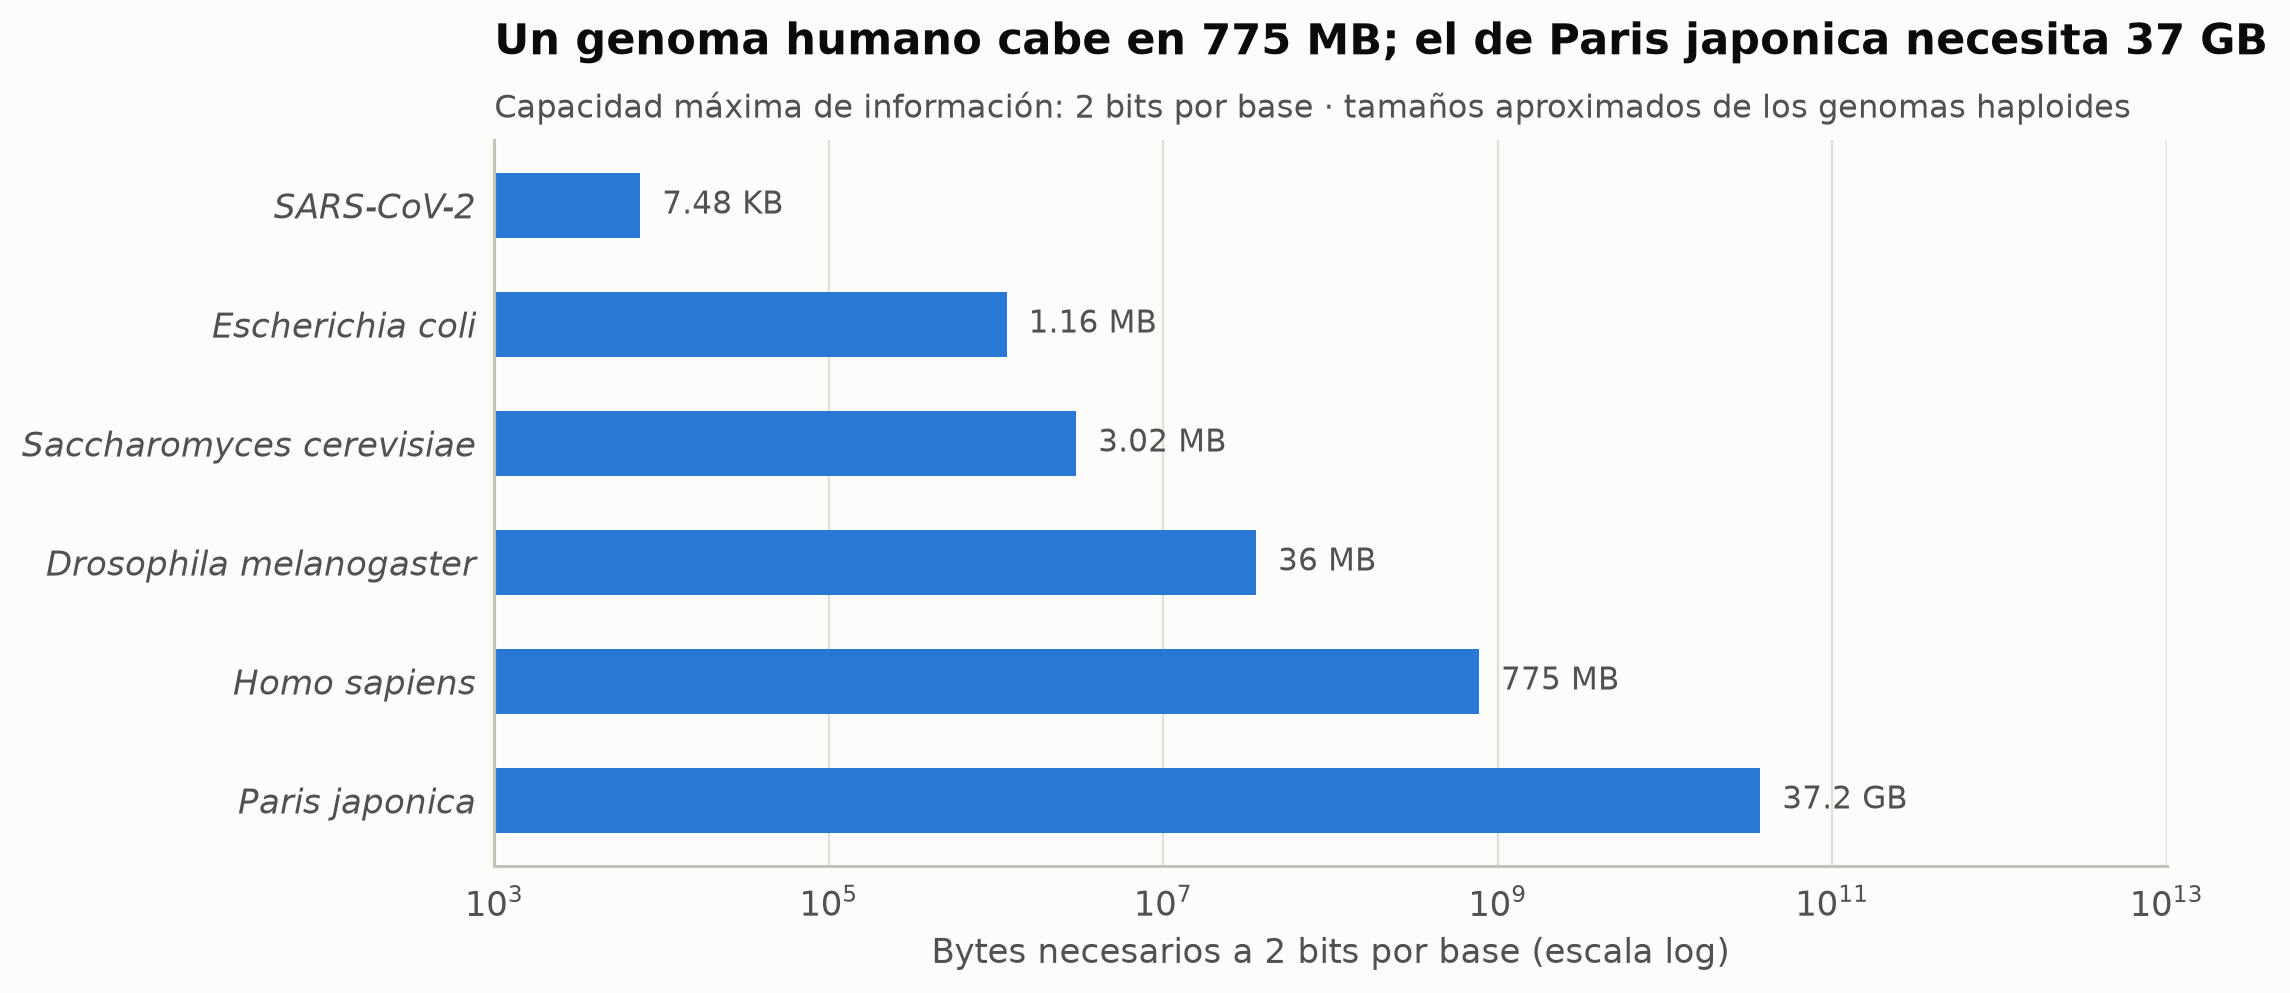

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.4))
y = np.arange(len(genomes))[::-1]
ax.barh(y, genomes["bytes_2bit"], color=ec.BLUE, height=0.55)
for yi, (b, name) in zip(y, zip(genomes["bytes_2bit"], genomes["organism"])):
    ax.text(b * 1.35, yi, human_size(b), va="center", fontsize=10, color=ec.INK_2)
ax.set_yticks(y, [f"{o}" for o in genomes["organism"]], style="italic")
ax.set_xscale("log"); ax.set_xlim(1e3, 1e13)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_xlabel("Bytes necesarios a 2 bits por base (escala log)")
ec.title(ax, "Un genoma humano cabe en 775 MB; el de Paris japonica necesita 37 GB",
         "Capacidad máxima de información: 2 bits por base · tamaños aproximados de los genomas haploides")
plt.show()

> 🔎 **Qué observamos.** Entre un virus y una planta hay **siete órdenes de magnitud**. Además, el tamaño del genoma
> no refleja la complejidad del organismo (una planta tiene un genoma 50 veces mayor que el humano): a esto se le
> llamó la **paradoja del valor C**, y se explica en gran parte por ADN repetitivo.

Pero atención: "2 bits por base" es la **capacidad máxima**, como decir que un libro de 300 páginas "podría" contener
300 páginas de información nueva. Si el libro repite la misma frase una y otra vez, contiene muy poca información
real. Necesitamos una medida que tenga en cuenta **qué tan predecible** es el texto.

## 4. Entropía de Shannon: medir la sorpresa de una secuencia

Imagine que lee una secuencia letra por letra y trata de adivinar la siguiente:

* En `AAAAAAAAAA…` nunca se sorprende: la siguiente letra es siempre `A`. Cada letra nueva **no le enseña nada**.
* En una secuencia donde A, C, G y T aparecen con la misma frecuencia, cada letra es una sorpresa total: necesita
  las 2 preguntas completas.
* En una secuencia con 90 % de A, la mayoría de las veces acierta diciendo "A": la sorpresa promedio es pequeña.

Claude Shannon (1948) definió la **sorpresa** de un evento de probabilidad $p$ como $-\log_2 p$ (un evento seguro,
$p=1$, sorprende 0 bits; uno rarísimo sorprende muchísimo) y la **entropía** como la **sorpresa promedio**:

$$
\boxed{\;H \;=\; -\sum_{x \in \{\mathtt{A},\mathtt{C},\mathtt{G},\mathtt{T}\}} p_x \,\log_2 p_x\;}
\qquad\qquad 0 \;\le\; H \;\le\; \log_2 4 = 2
$$

| Símbolo | Significado |
|---|---|
| $x$ | cada una de las letras posibles (A, C, G, T) |
| $p_x$ | frecuencia (probabilidad) de la letra $x$ en la secuencia |
| $-\log_2 p_x$ | la **sorpresa** de ver la letra $x$, en bits |
| $\sum$ | promedio ponderado: cada sorpresa pesa según lo frecuente que es |
| $H$ | entropía: bits de información por base, en promedio |
| convención | $0 \cdot \log_2 0 = 0$ (una letra que nunca aparece no aporta) |

**Ejemplos a mano:**

| Composición $(p_A, p_C, p_G, p_T)$ | Cálculo | $H$ |
|---|---|---|
| $(1, 0, 0, 0)$ | $-1\cdot\log_2 1 = 0$ | **0 bits** |
| $(\tfrac12, 0, 0, \tfrac12)$ | $-2 \cdot \tfrac12 \log_2 \tfrac12 = 1$ | **1 bit** |
| $(\tfrac14, \tfrac14, \tfrac14, \tfrac14)$ | $-4 \cdot \tfrac14 \log_2 \tfrac14 = 2$ | **2 bits** |
| $(0.7, 0.1, 0.1, 0.1)$ | $-(0.7\log_2 0.7 + 3\cdot 0.1\log_2 0.1)$ | **≈ 1.36 bits** |

Una sola letra = sin información; todas iguales = máxima información.

In [10]:
def shannon_entropy(seq: str, k: int = 1) -> float:
    """Entropía de Shannon (bits) de las 'palabras' de longitud k de una secuencia (k=1: bases sueltas)."""
    words = [seq[i:i + k] for i in range(len(seq) - k + 1)]
    counts = np.array(list(pd.Series(words).value_counts()))
    p = counts / counts.sum()
    return abs(float(-(p * np.log2(p)).sum()))       # abs() evita imprimir "-0.0"

# Verificamos los ejemplos hechos a mano
for s in ["AAAAAAAA", "ATATATAT", "ACGTACGT"]:
    print(f"{s}: H = {shannon_entropy(s):.3f} bits")

p = np.array([0.7, 0.1, 0.1, 0.1])
print(f"(0.7, 0.1, 0.1, 0.1): H = {-(p * np.log2(p)).sum():.3f} bits")

AAAAAAAA: H = 0.000 bits
ATATATAT: H = 1.000 bits
ACGTACGT: H = 2.000 bits
(0.7, 0.1, 0.1, 0.1): H = 1.357 bits


Para una secuencia con sólo dos letras posibles (por ejemplo, sólo interesa si una base es "GC" o "AT"), la
entropía depende de un único número $p$. Esta curva, la **entropía binaria**, es la forma más clara de ver que la
información es máxima cuando todo es igualmente probable:

$$
H_2(p) = -p\log_2 p - (1-p)\log_2(1-p)
$$

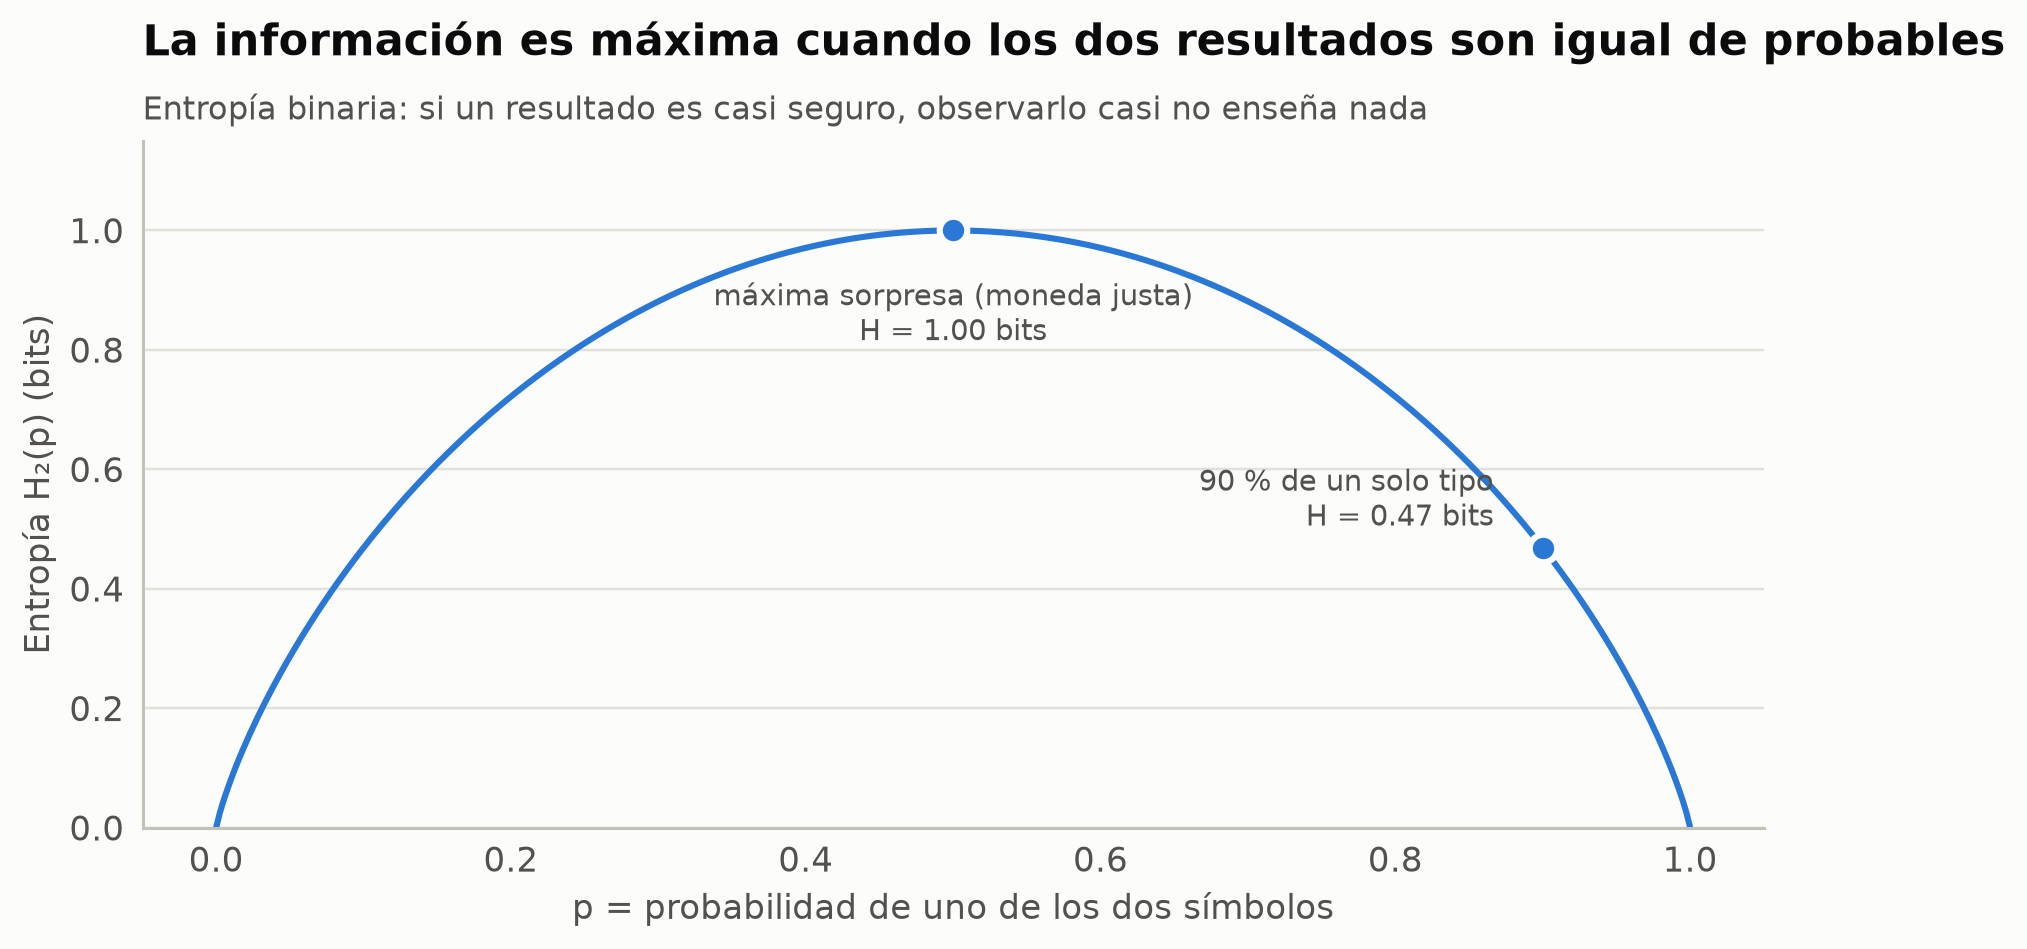

In [11]:
pgrid = np.linspace(1e-4, 1 - 1e-4, 400)
H2 = -pgrid * np.log2(pgrid) - (1 - pgrid) * np.log2(1 - pgrid)
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(pgrid, H2, color=ec.BLUE)
for pp, lab, off, ha in [(0.5, "máxima sorpresa (moneda justa)", (0, -16), "center"),
                        (0.9, "90 % de un solo tipo", (-16, 4), "right")]:
    hh = -pp * np.log2(pp) - (1 - pp) * np.log2(1 - pp)
    ax.plot(pp, hh, "o", color=ec.BLUE, markersize=9, markeredgecolor=ec.SURFACE, markeredgewidth=2)
    ax.annotate(f"{lab}\nH = {hh:.2f} bits", (pp, hh), xytext=off, textcoords="offset points",
                fontsize=9.5, color=ec.INK_2, va="top" if off[1] < 0 else "bottom", ha=ha)
ax.set_xlabel("p = probabilidad de uno de los dos símbolos")
ax.set_ylabel("Entropía H₂(p) (bits)")
ax.set_ylim(0, 1.15)
ec.title(ax, "La información es máxima cuando los dos resultados son igual de probables",
         "Entropía binaria: si un resultado es casi seguro, observarlo casi no enseña nada")
plt.show()

### 🧪 Tres secuencias, tres niveles de información

🤔 **Antes de ejecutar, prediga:** ordene de mayor a menor entropía estas tres secuencias:
(a) una secuencia **aleatoria** con las 4 bases equiprobables, (b) el **genoma real** de SARS-CoV-2 y
(c) una **repetición** `CAG CAG CAG…` (como las que causan la enfermedad de Huntington cuando se expanden).

Además de la entropía de bases sueltas ($k=1$), calcularemos la de **pares** ($k=2$) y **tripletes** ($k=3$)
dividida entre $k$: así vemos si la secuencia tiene estructura que se nota sólo al mirar vecinos (una repetición
`CAG` tiene tres letras distintas, pero sus pares son muy predecibles).

In [12]:
rng = np.random.default_rng(11)
real = str(genome.seq)
seqs = {
    "Aleatoria (equiprobable)": "".join(rng.choice(list("ACGT"), len(real))),
    "SARS-CoV-2 (real)": real,
    "Repetición CAG": ("CAG" * (len(real) // 3 + 1))[:len(real)],
}
rows = []
for name, s in seqs.items():
    for k in (1, 2, 3):
        rows.append({"secuencia": name, "k": k, "bits_por_base": shannon_entropy(s, k) / k})
ent = pd.DataFrame(rows)
ent.pivot(index="secuencia", columns="k", values="bits_por_base").round(3)

k,1,2,3
secuencia,,,
Aleatoria (equiprobable),2.000,2.000,2.000
Repetición CAG,1.585,0.792,0.528
SARS-CoV-2 (real),1.957,1.941,1.933


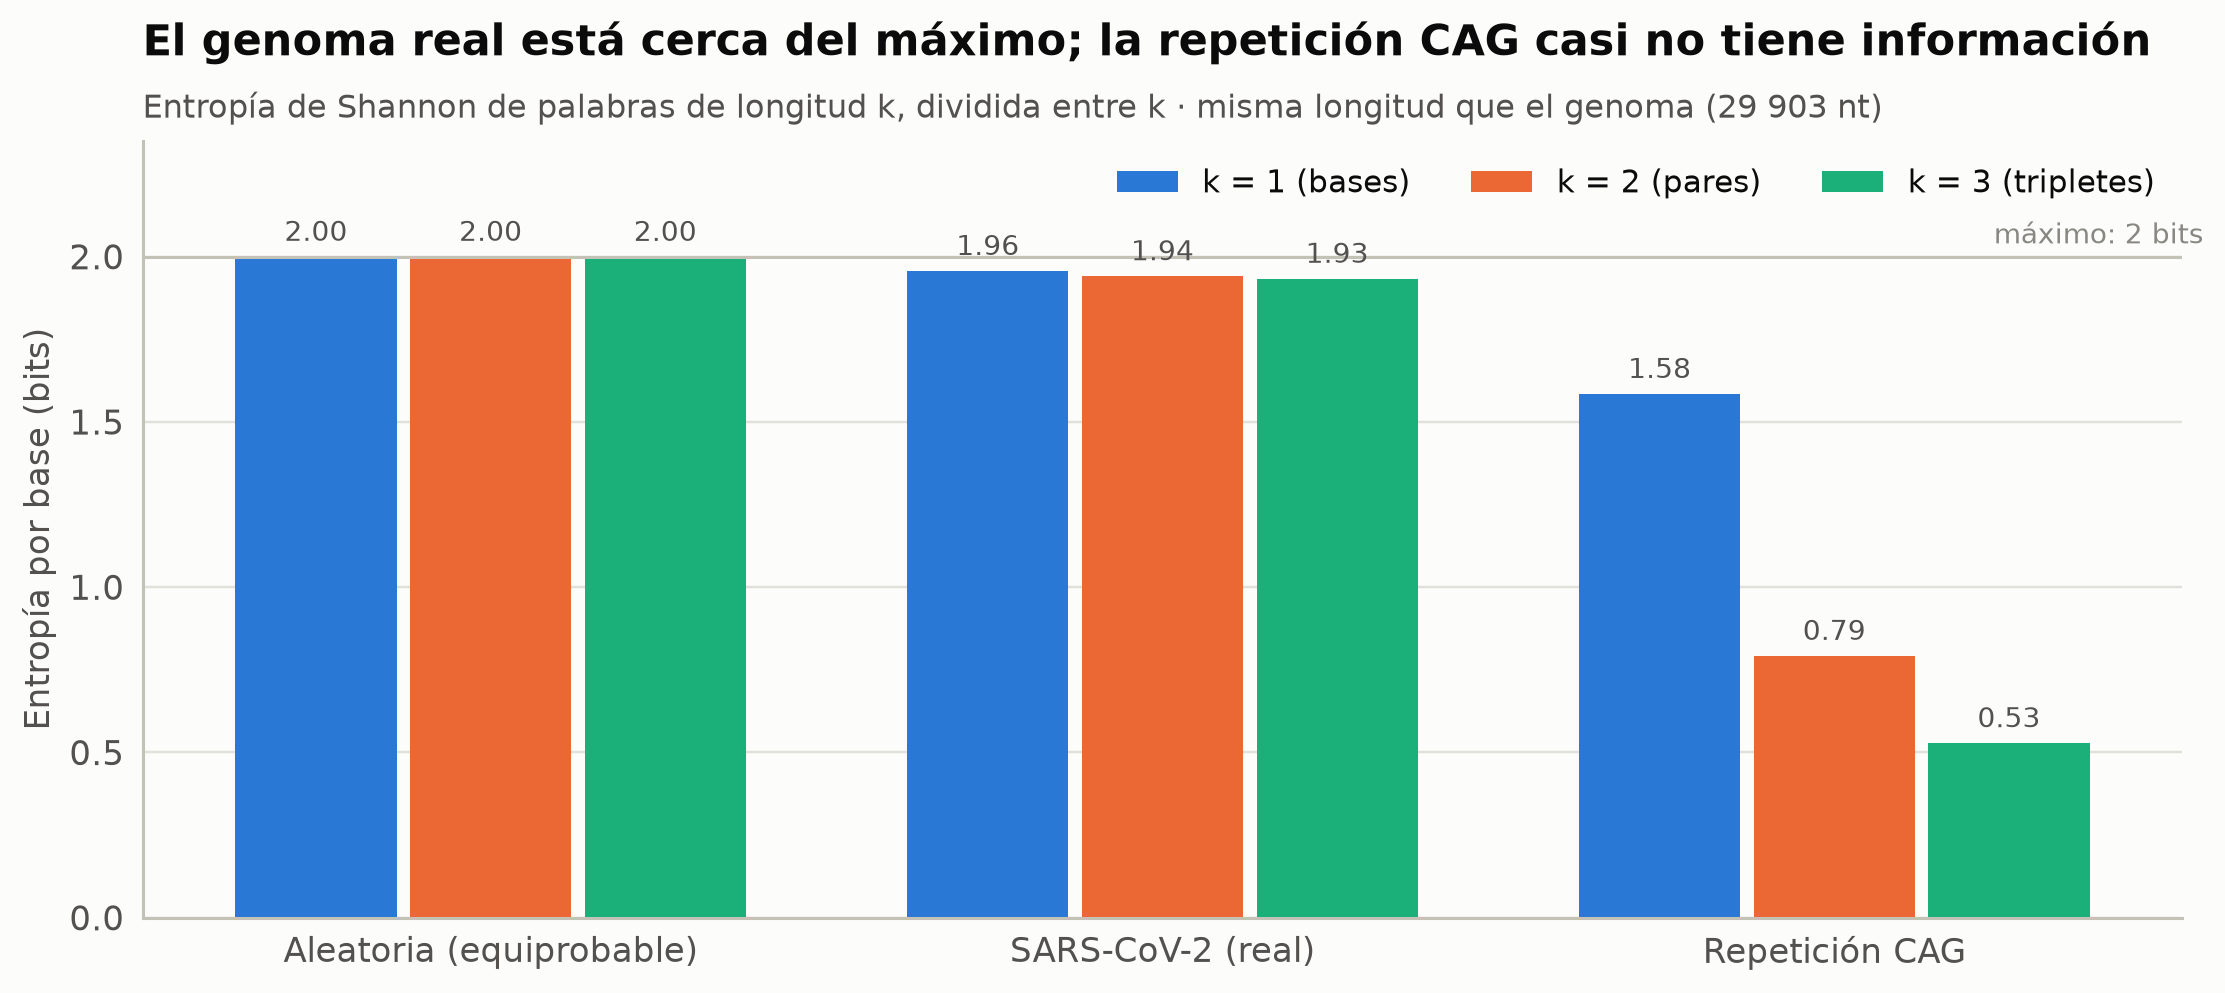

In [13]:
fig, ax = plt.subplots(figsize=(10, 4.4))
names = list(seqs)
width = 0.24
for i, k in enumerate((1, 2, 3)):
    vals = [ent.query("secuencia == @n and k == @k")["bits_por_base"].item() for n in names]
    bars = ax.bar(np.arange(3) + (i - 1) * (width + 0.02), vals, width, color=ec.CATEGORICAL[i],
                  label=f"k = {k} ({['bases', 'pares', 'tripletes'][i]})")
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9, color=ec.INK_2)
ax.axhline(2, color=ec.BASELINE, lw=1)
ax.text(2.55, 2.02, "máximo: 2 bits", color=ec.MUTED, fontsize=9, ha="right", va="bottom")
ax.set_xticks(range(3), names)
ax.set_ylabel("Entropía por base (bits)")
ax.set_ylim(0, 2.35)
ax.legend(loc="upper right", ncol=3, bbox_to_anchor=(1, 1.0))
ec.title(ax, "El genoma real está cerca del máximo; la repetición CAG casi no tiene información",
         "Entropía de Shannon de palabras de longitud k, dividida entre k · misma longitud que el genoma (29 903 nt)")
plt.show()

> 🔎 **Qué observamos.**
> * La secuencia **aleatoria** tiene ≈ 2 bits por base con cualquier $k$: no hay ningún patrón.
> * **SARS-CoV-2** tiene algo menos de 2 bits: su composición no es uniforme (es rico en U/T y pobre en C y G) y
>   tiene algo de estructura entre vecinos, pero **a simple vista parece casi aleatorio**. La información biológica
>   no está en la frecuencia de las letras sino en *qué dicen*, igual que un texto en español y un texto con las
>   mismas letras desordenadas tienen casi la misma entropía de letras sueltas.
> * La **repetición CAG** tiene $\log_2 3 \approx 1.58$ bits con $k=1$ (tres letras equiprobables), pero con $k=2$
>   y $k=3$ cae a ≈ 0.5: una vez que conoce una letra, la siguiente es completamente predecible.

## 5. 🧪 Experimento: la entropía a lo largo del genoma (interactivo)

Las regiones de **baja complejidad** (repeticiones, colas poli-A) tienen entropía local baja y suelen dar problemas
a los alineadores; por eso herramientas como BLAST las enmascaran (filtros DUST y SEG). Calculemos la entropía en
ventanas de 100 nt a lo largo del genoma. **Pase el ratón** sobre la curva: verá la posición, la entropía, el gen
en que cae la ventana y su composición.

In [14]:
window, stepw = 100, 20
starts = np.arange(0, len(real) - window + 1, stepw)
cds = [(int(f.location.start), int(f.location.end), f.qualifiers["gene"][0])
       for f in genome.features if f.type == "CDS"]

def gene_at(pos):
    hits = [g for s, e, g in cds if s <= pos < e]
    return hits[0] if hits else "región no codificante"

win_rows = []
for s0 in starts:
    w = real[s0:s0 + window]
    win_rows.append({"centro": s0 + window // 2, "H": shannon_entropy(w),
                     "gen": gene_at(s0 + window // 2),
                     "comp": " ".join(f"{b}:{w.count(b)}" for b in "ACGT")})
win = pd.DataFrame(win_rows)
low = win.nsmallest(1, "H").iloc[0]
print(f"Ventana de menor entropía: centro {low['centro']:,} nt · H = {low['H']:.2f} · {low['gen']} · {low['comp']}")
print("Secuencia:", real[int(low['centro']) - 50:int(low['centro']) + 50])

Ventana de menor entropía: centro 29,850 nt · H = 1.72 · región no codificante · A:51 C:11 G:12 T:26
Secuencia: CCCTAATGTGTAAAATTAATTTTAGTAGTGCTATCCCCATGTGATTTTAATAGCTTCTTAGGAGAATGACAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA


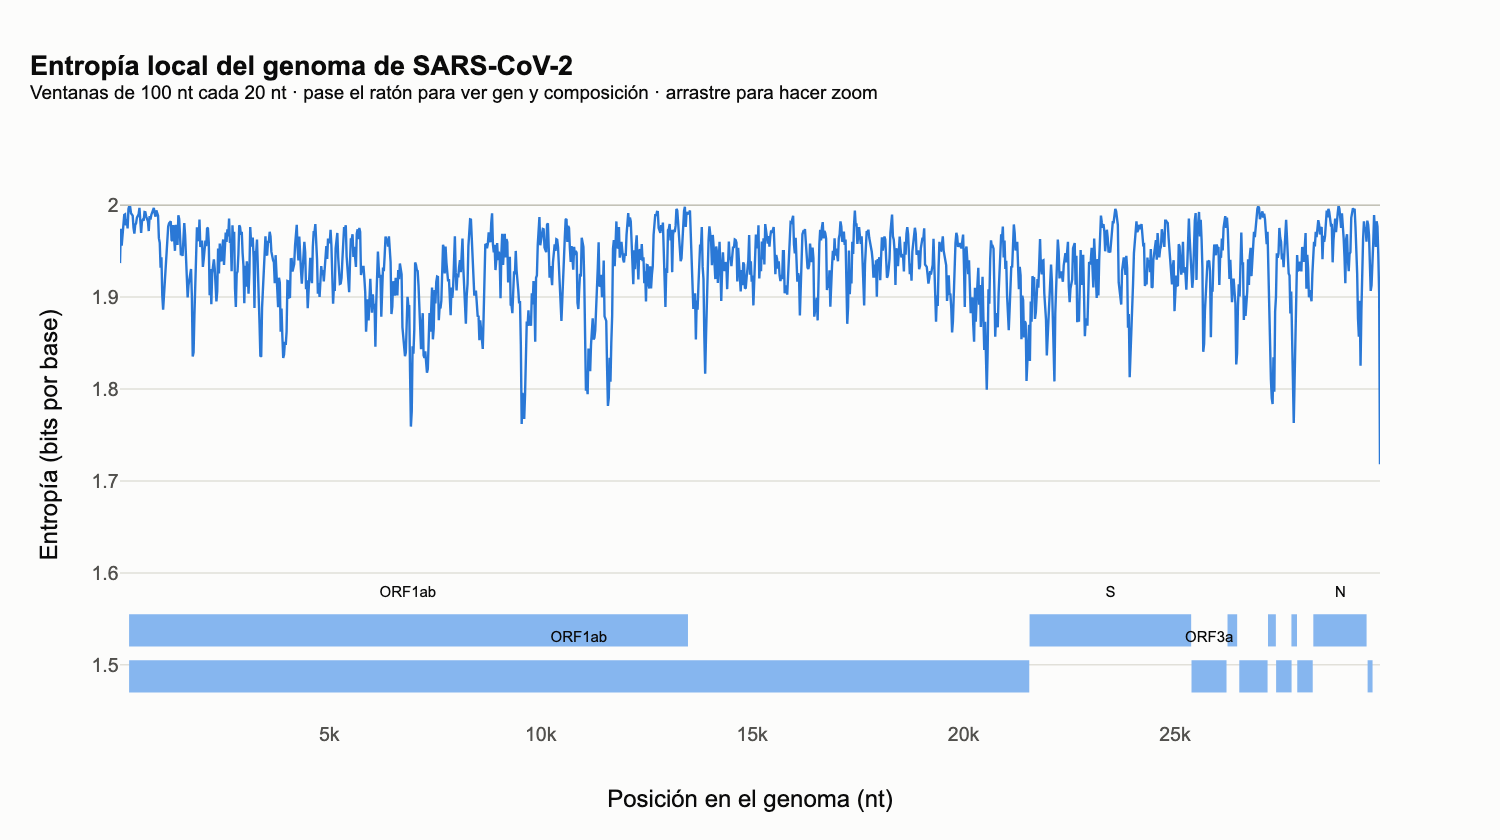

In [15]:
figp = go.Figure()
figp.add_trace(go.Scatter(
    x=win["centro"], y=win["H"], mode="lines", line=dict(color=ec.BLUE, width=1.6), name="entropía",
    customdata=np.stack([win["gen"], win["comp"]], axis=1),
    hovertemplate="<b>posición %{x:,} nt</b><br>H = %{y:.2f} bits<br>gen: %{customdata[0]}"
                  "<br>composición: %{customdata[1]}<extra></extra>"))
# Pista de genes (rectángulos alternados) debajo de la curva
for i, (s0, e0, g) in enumerate(sorted({(s, e, g) for s, e, g in cds})):
    y0 = 1.52 if i % 2 == 0 else 1.47
    figp.add_shape(type="rect", x0=s0, x1=e0, y0=y0, y1=y0 + 0.035, fillcolor=ec.SEQ_BLUE[3], line_width=0)
    if e0 - s0 > 800:
        figp.add_annotation(x=(s0 + e0) / 2, y=y0 + 0.06, text=g, showarrow=False, font=dict(size=10, color=ec.INK))
figp.add_hline(y=2, line=dict(color=ec.BASELINE, width=1))
figp.update_layout(
    title=dict(text="<b>Entropía local del genoma de SARS-CoV-2</b><br><sup>Ventanas de 100 nt cada 20 nt · "
                    "pase el ratón para ver gen y composición · arrastre para hacer zoom</sup>"),
    xaxis_title="Posición en el genoma (nt)", yaxis_title="Entropía (bits por base)",
    yaxis_range=[1.44, 2.06], height=460, showlegend=False, hovermode="x unified")
figp.show()

> 🔎 **Qué observamos.** Casi todo el genoma oscila entre 1.8 y 2 bits por base. Las caídas más profundas suelen
> estar en los extremos (la cola poli-A del extremo 3' es el caso extremo: una sola letra repetida) o en tramos
> ricos en una sola base. Estas regiones de baja complejidad son las primeras que conviene inspeccionar cuando
> un análisis de alineamiento da resultados extraños.

## 6. 🧪 Experimento: compresión, la información medida "a la fuerza bruta"

Hay otra manera, muy práctica, de medir información: **intentar comprimir** el texto. Un compresor como `gzip`
busca repeticiones y las reemplaza por referencias del tipo "copiar los 30 caracteres de hace 200 posiciones". Si
un texto es muy repetitivo, se comprime muchísimo; si es impredecible, casi no se comprime. Es como resumir una
película: "y luego se repite la misma escena diez veces" ahorra mucho espacio.

Mediremos los **bits por base después de comprimir**:

$$
b \;=\; \frac{8 \times \text{bytes comprimidos}}{\text{número de bases}}
$$

| Símbolo | Significado |
|---|---|
| bytes comprimidos | tamaño del archivo después de `gzip` |
| $8\times$ | cada byte tiene 8 bits |
| $b$ | bits que el compresor necesitó por cada base (sin comprimir: 8 bits, un carácter ASCII) |

🤔 **Antes de ejecutar, prediga:** ¿llegará `gzip` a 2 bits por base con la secuencia aleatoria? ¿Y con el genoma real?

In [16]:
import gzip

comp_rows = []
for name, s in seqs.items():
    raw = s.encode()
    z = gzip.compress(raw, compresslevel=9)
    comp_rows.append({"secuencia": name, "bits_por_base_gzip": 8 * len(z) / len(raw),
                      "entropia_k3": ent.query("secuencia == @name and k == 3")["bits_por_base"].item()})
comp = pd.DataFrame(comp_rows)
comp.round(3)

,secuencia,bits_por_base_gzip,entropia_k3
0,Aleatoria (equiprobable),2.486,2.000
1,SARS-CoV-2 (real),2.395,1.933
2,Repetición CAG,0.018,0.528


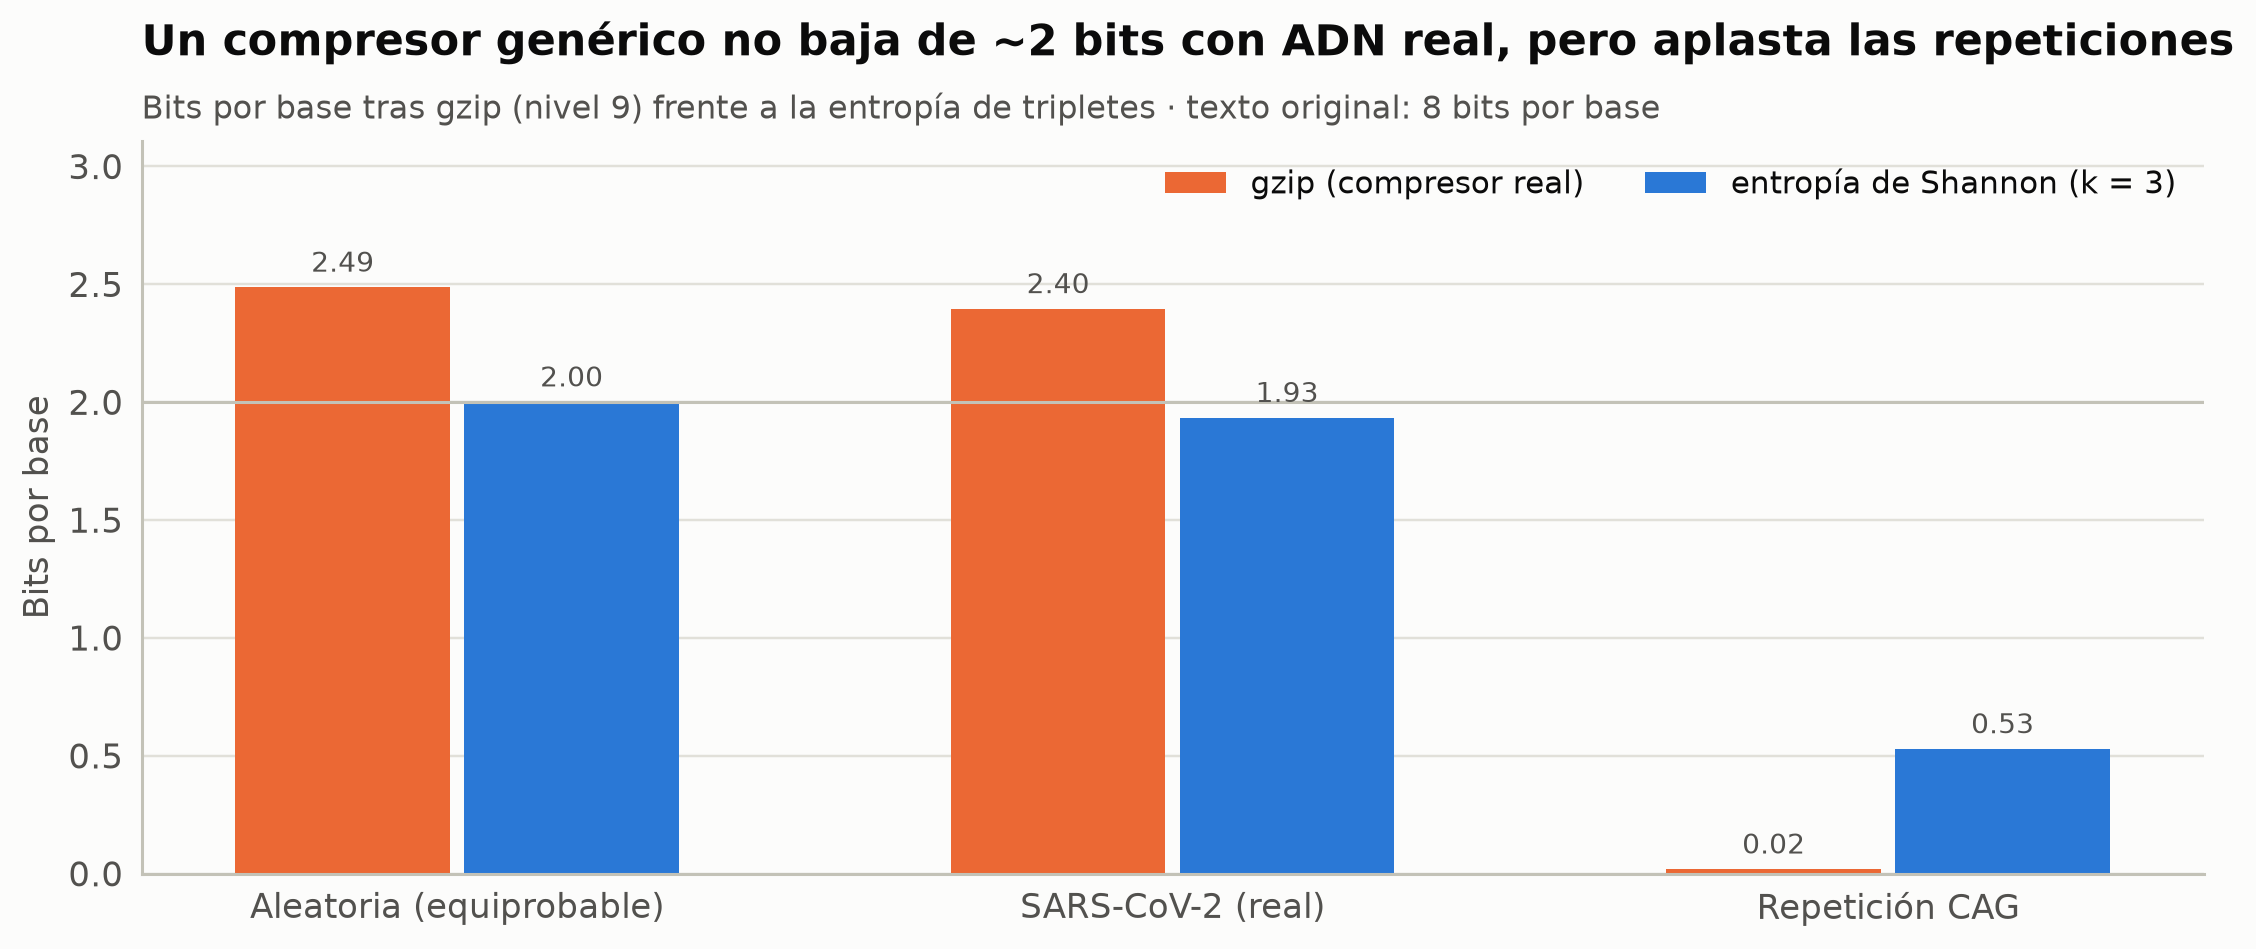

In [17]:
fig, ax = plt.subplots(figsize=(10, 4.2))
x = np.arange(len(comp))
b1 = ax.bar(x - 0.16, comp["bits_por_base_gzip"], 0.3, color=ec.ORANGE, label="gzip (compresor real)")
b2 = ax.bar(x + 0.16, comp["entropia_k3"], 0.3, color=ec.BLUE, label="entropía de Shannon (k = 3)")
ax.bar_label(b1, fmt="%.2f", padding=3, fontsize=9, color=ec.INK_2)
ax.bar_label(b2, fmt="%.2f", padding=3, fontsize=9, color=ec.INK_2)
ax.axhline(2, color=ec.BASELINE, lw=1)
ax.set_xticks(x, comp["secuencia"])
ax.set_ylabel("Bits por base")
ax.set_ylim(0, max(comp["bits_por_base_gzip"].max(), 2) * 1.25)
ax.legend(loc="upper right", ncol=2)
ec.title(ax, "Un compresor genérico no baja de ~2 bits con ADN real, pero aplasta las repeticiones",
         "Bits por base tras gzip (nivel 9) frente a la entropía de tripletes · texto original: 8 bits por base")
plt.show()

> 🔎 **Qué observamos.** Para la secuencia aleatoria y el genoma real, `gzip` queda **por encima** de 2 bits por base:
> ni siquiera alcanza la codificación trivial de 2 bits, porque está diseñado para texto humano y no "sabe" que sólo
> hay 4 letras. Con la repetición CAG, en cambio, comprime a una fracción mínima. Por eso existen compresores
> especializados para genomas, y por eso los formatos de lecturas (FASTQ comprimido, CRAM) son un campo activo de
> investigación: un solo experimento de secuenciación puede ocupar cientos de GB.

## 7. 🧪 Experimento: ¿qué tan robusto es el código genético?

Cuando el ADN se replica, la polimerasa se equivoca de vez en cuando: cambia una base por otra (**mutación
puntual** o SNV). ¿Qué le pasa a la proteína? Hay tres posibilidades:

| Tipo | Qué ocurre | Ejemplo |
|---|---|---|
| **Sinónima** (silenciosa) | el codón cambia pero codifica **el mismo** aminoácido | `CTT` (Leu) → `CTC` (Leu) |
| **Sin sentido** (*missense*) | cambia a **otro** aminoácido | `CTT` (Leu) → `CCT` (Pro) |
| **Terminadora** (*nonsense*) | aparece un **codón de parada** prematuro | `TGG` (Trp) → `TGA` (stop) |

El código genético se parece a un teclado bien diseñado donde las teclas vecinas escriben letras parecidas: si se
equivoca de tecla, a menudo el mensaje sigue siendo legible. Vamos a comprobarlo **exhaustivamente**: en el gen
Spike real (1 273 codones), probaremos **todas** las mutaciones puntuales posibles: 3 posiciones × 3 bases
alternativas por codón.

**Ejemplo a mano** con el codón `CTT` (Leu):

| Posición mutada | Alternativas | Resultado |
|---|---|---|
| 1ª | `ATT` Ile · `GTT` Val · `TTT` Phe | 3 *missense* |
| 2ª | `CAT` His · `CCT` Pro · `CGT` Arg | 3 *missense* |
| 3ª | `CTA` · `CTC` · `CTG` | **3 sinónimas** (todas Leu) |

🤔 **Antes de ejecutar, prediga:** ¿en qué posición del codón serán más frecuentes las mutaciones sinónimas?

In [18]:
DNA_TABLE = {c.replace("U", "T"): aa for c, aa in CODON_TABLE.items()}

def classify(orig_aa, new_aa):
    if new_aa == orig_aa: return "sinónima"
    if new_aa == "*":     return "terminadora"
    return "missense"

mut_rows = []
codons = [spike_dna[i:i + 3] for i in range(0, len(spike_dna) - 3, 3)]      # sin el codón de parada
for ci, codon in enumerate(codons):
    aa = DNA_TABLE[codon]
    for pos in range(3):
        for b in "ACGT":
            if b == codon[pos]: continue
            mutant = codon[:pos] + b + codon[pos + 1:]
            new = DNA_TABLE[mutant]
            mut_rows.append({"codon_index": ci + 1, "codon": codon, "aa": aa, "position": pos + 1,
                             "mutant": mutant, "new_aa": new, "effect": classify(aa, new)})
muts = pd.DataFrame(mut_rows)
print(f"{len(muts):,} mutaciones puntuales evaluadas en {len(codons):,} codones")
summary = pd.crosstab(muts["position"], muts["effect"], normalize="index").mul(100).round(1)
summary = summary[["sinónima", "missense", "terminadora"]]
summary

11,457 mutaciones puntuales evaluadas en 1,273 codones


effect,sinónima,missense,terminadora
position,,,
1,2.4,92.1,5.4
2,0.0,96.3,3.7
3,64.1,31.7,4.2


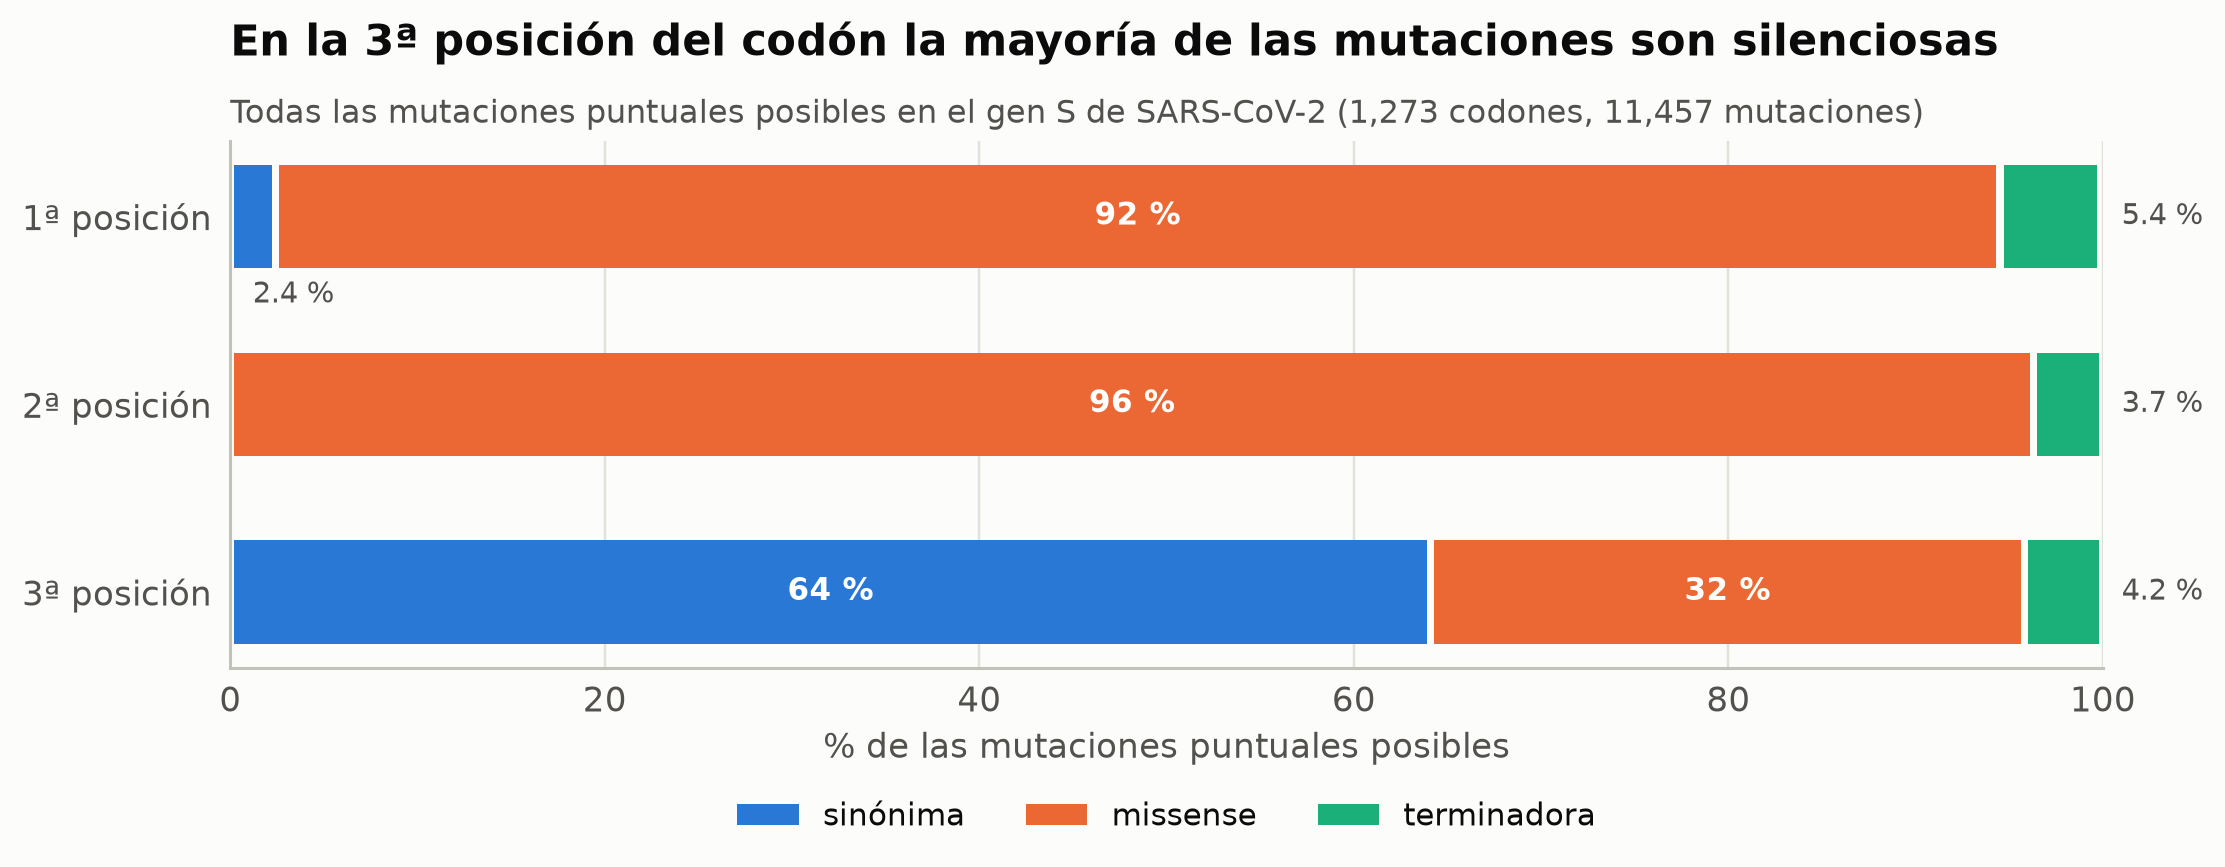

In [19]:
effects = ["sinónima", "missense", "terminadora"]
colors = {"sinónima": ec.BLUE, "missense": ec.ORANGE, "terminadora": ec.AQUA}
fig, ax = plt.subplots(figsize=(10, 3.8))
for yi, pos in enumerate([3, 2, 1]):
    left = 0
    for eff in effects:
        v = summary.loc[pos, eff]
        ax.barh(yi, v - 0.4 if v > 1 else v, left=left + (0.2 if v > 1 else 0), height=0.55, color=colors[eff])
        if v >= 6:
            ax.text(left + v / 2, yi, f"{v:.0f} %", ha="center", va="center", fontsize=10,
                    color="white", fontweight="bold")
        elif v > 0 and eff == "terminadora":          # segmento final angosto: etiqueta a la derecha
            ax.text(101, yi, f"{v:.1f} %", ha="left", va="center", fontsize=9.5, color=ec.INK_2)
        elif v > 0:                                   # segmento inicial angosto: etiqueta encima
            ax.text(left + v / 2, yi - 0.34, f"{v:.1f} %", ha="left", va="top", fontsize=9.5, color=ec.INK_2)
        left += v
ax.set_yticks(range(3), ["3ª posición", "2ª posición", "1ª posición"])
ax.set_xlim(0, 100); ax.set_xlabel("% de las mutaciones puntuales posibles")
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[e]) for e in effects]
ax.legend(handles, effects, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.2), fontsize=10)
ec.title(ax, "En la 3ª posición del codón la mayoría de las mutaciones son silenciosas",
         f"Todas las mutaciones puntuales posibles en el gen S de SARS-CoV-2 ({len(codons):,} codones, {len(muts):,} mutaciones)")
plt.show()

> 🔎 **Qué observamos.** En la **2ª posición** casi todas las mutaciones cambian el aminoácido; en la **3ª**, la
> mayoría son sinónimas. La razón está en la tabla del código genético (Lección 0.2): los codones de un mismo
> aminoácido suelen diferir **sólo en la tercera letra** (`GCT`, `GCC`, `GCA`, `GCG` son todos alanina). Crick llamó
> a esto *wobble* ("bamboleo"): el ARNt se aparea con firmeza en las dos primeras posiciones y con holgura en la
> tercera, de modo que un mismo ARNt puede leer varios codones.
>
> Consecuencia práctica, que usaremos en genómica evolutiva: comparar la tasa de cambios **no sinónimos** ($d_N$)
> con la de **sinónimos** ($d_S$) permite detectar genes bajo selección.

### Explorador interactivo de mutaciones del gen S

Cada columna es un codón de Spike y cada fila una posición del codón. El color indica **cuántas de las 3 mutaciones
posibles** en esa posición son sinónimas. Pase el ratón para ver el codón, el aminoácido y el resultado de cada
mutación; haga zoom para inspeccionar regiones.

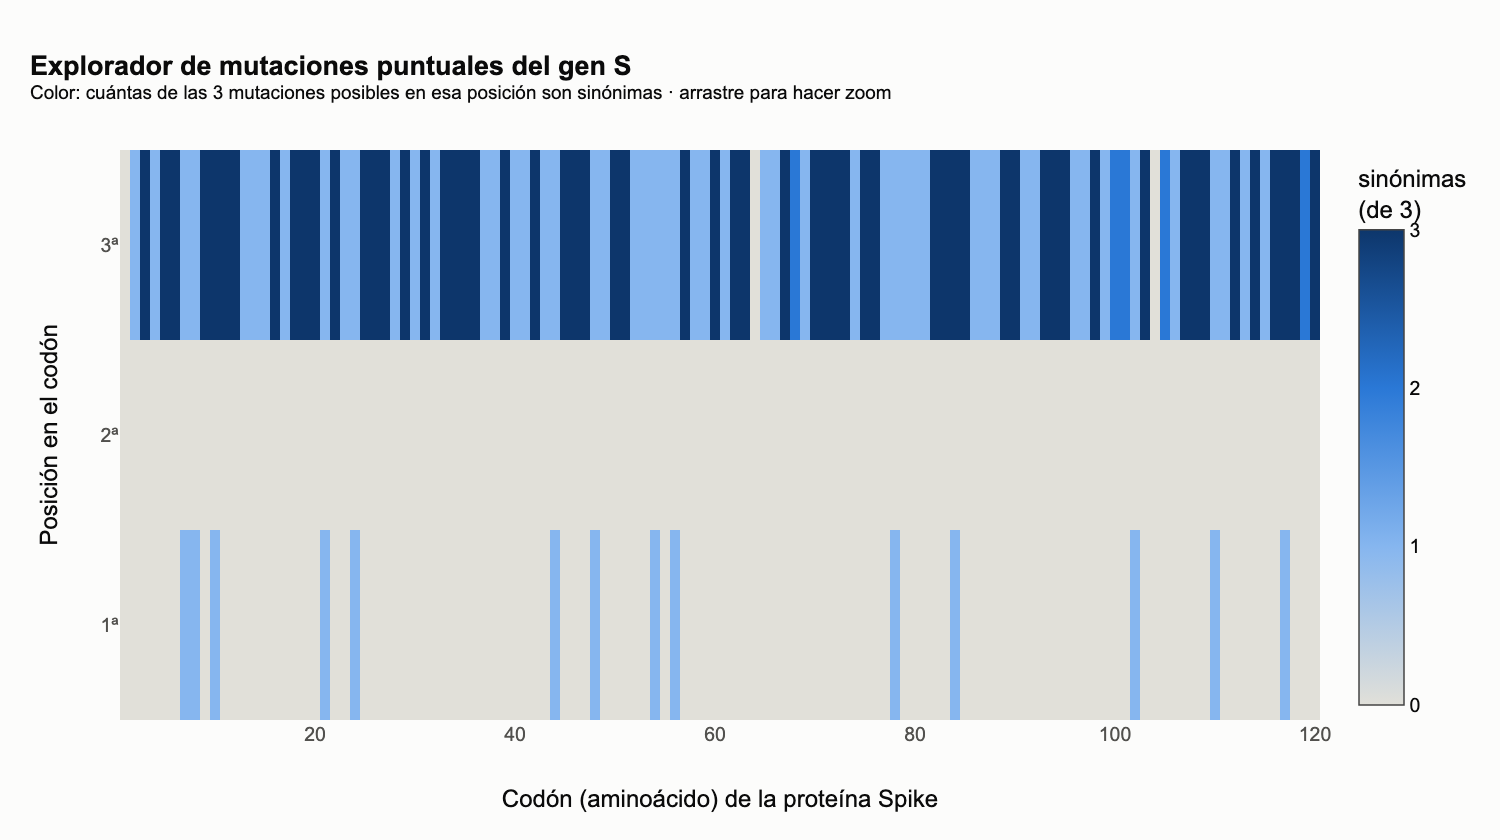

In [20]:
three_stop = {**three, "*": "STOP"}
detail = (muts.assign(txt=lambda d: d["mutant"] + "→" + d["new_aa"].map(three_stop) + " (" + d["effect"] + ")")
              .groupby(["codon_index", "position"])
              .agg(syn=("effect", lambda e: (e == "sinónima").sum()), codon=("codon", "first"),
                   aa=("aa", "first"), txt=("txt", lambda t: "<br>".join(t)))
              .reset_index())
z = detail.pivot(index="position", columns="codon_index", values="syn").values
hover = detail.pivot(index="position", columns="codon_index", values="txt").values
cod = detail.pivot(index="position", columns="codon_index", values="codon").values
aas = detail.pivot(index="position", columns="codon_index", values="aa").map(lambda a: three.get(a, a)).values
custom = np.dstack([cod, aas, hover])

figh = go.Figure(go.Heatmap(
    z=z, x=np.arange(1, z.shape[1] + 1), y=["1ª", "2ª", "3ª"], customdata=custom,
    colorscale=[[0, ec.GRID], [1 / 3, ec.SEQ_BLUE[3]], [2 / 3, ec.SEQ_BLUE[7]], [1, ec.SEQ_BLUE[12]]],
    zmin=0, zmax=3, colorbar=dict(title="sinónimas<br>(de 3)", tickvals=[0, 1, 2, 3]),
    hovertemplate="<b>codón %{x}: %{customdata[0]} (%{customdata[1]})</b> · posición %{y}<br>"
                  "%{customdata[2]}<extra></extra>"))
figh.update_layout(
    title=dict(text="<b>Explorador de mutaciones puntuales del gen S</b><br><sup>Color: cuántas de las 3 "
                    "mutaciones posibles en esa posición son sinónimas · arrastre para hacer zoom</sup>"),
    xaxis_title="Codón (aminoácido) de la proteína Spike", yaxis_title="Posición en el codón",
    height=380, xaxis=dict(range=[0.5, 120.5]))
figh.show()

### ¿Es el código genético "uno en un millón"?

Que la 3ª posición sea tolerante es bueno, pero la pregunta profunda es otra: cuando una mutación **sí** cambia el
aminoácido, ¿lo cambia por uno **parecido**? Si el código estuviera organizado al azar, un error cambiaría con la
misma facilidad un aminoácido hidrofóbico (que va escondido en el interior de la proteína) por uno cargado (que
prefiere el agua), lo cual suele destruir el plegamiento.

Mediremos el "daño" con la **hidropatía** de Kyte y Doolittle ($h$: positivo = hidrofóbico, negativo = hidrofílico) y
definimos el **costo** de un código como el cambio cuadrático medio de hidropatía causado por todas las mutaciones
puntuales *missense* posibles:

$$
\Phi(g) \;=\; \frac{1}{|M|} \sum_{(c \to c') \in M} \Big( h\big(g(c)\big) - h\big(g(c')\big) \Big)^2
$$

| Símbolo | Significado |
|---|---|
| $g$ | un código genético (una tabla codón → aminoácido) |
| $c \to c'$ | una mutación puntual del codón $c$ al codón $c'$ (difieren en una sola base) |
| $M$ | el conjunto de todas esas mutaciones entre codones con sentido (sin paradas) |
| $\lvert M \rvert$ | cuántas mutaciones hay en $M$ |
| $h(\cdot)$ | hidropatía del aminoácido (escala de Kyte–Doolittle) |
| $\Phi(g)$ | costo del código: **cuanto menor, más robusto** |

Para comparar, generamos **códigos alternativos**: mantenemos los mismos "bloques" de codones sinónimos del código
real, pero **barajamos** qué aminoácido le corresponde a cada bloque (como reasignar al azar las etiquetas de los
cajones de un armario sin cambiar los cajones). Este es el experimento clásico de Freeland y Hurst (1998).

In [21]:
KD = {"A": 1.8, "R": -4.5, "N": -3.5, "D": -3.5, "C": 2.5, "Q": -3.5, "E": -3.5, "G": -0.4, "H": -3.2, "I": 4.5,
      "L": 3.8, "K": -3.9, "M": 1.9, "F": 2.8, "P": -1.6, "S": -0.8, "T": -0.7, "W": -0.9, "Y": -1.3, "V": 4.2}
sense = [c for c, a in DNA_TABLE.items() if a != "*"]
pairs = [(c, c[:p] + b + c[p + 1:]) for c in sense for p in range(3) for b in "ACGT"
         if b != c[p] and DNA_TABLE[c[:p] + b + c[p + 1:]] != "*"]

def code_cost(table):
    return np.mean([(KD[table[a]] - KD[table[b]]) ** 2 for a, b in pairs])

aa_list = sorted(KD)
standard_cost = code_cost(DNA_TABLE)
rng = np.random.default_rng(1998)
random_costs = []
for _ in range(3000):
    perm = dict(zip(aa_list, rng.permutation(aa_list)))          # reasigna aminoácidos entre bloques
    random_costs.append(code_cost({c: perm[a] for c, a in DNA_TABLE.items() if a != "*"}))
random_costs = np.array(random_costs)
better = (random_costs <= standard_cost).mean()
print(f"Costo del código estándar: {standard_cost:.2f}")
print(f"Costo medio de los códigos al azar: {random_costs.mean():.2f}")
print(f"Fracción de códigos al azar tan buenos o mejores: {better:.4f} ({(random_costs <= standard_cost).sum()} de {len(random_costs)})")

Costo del código estándar: 9.39
Costo medio de los códigos al azar: 13.31
Fracción de códigos al azar tan buenos o mejores: 0.0073 (22 de 3000)


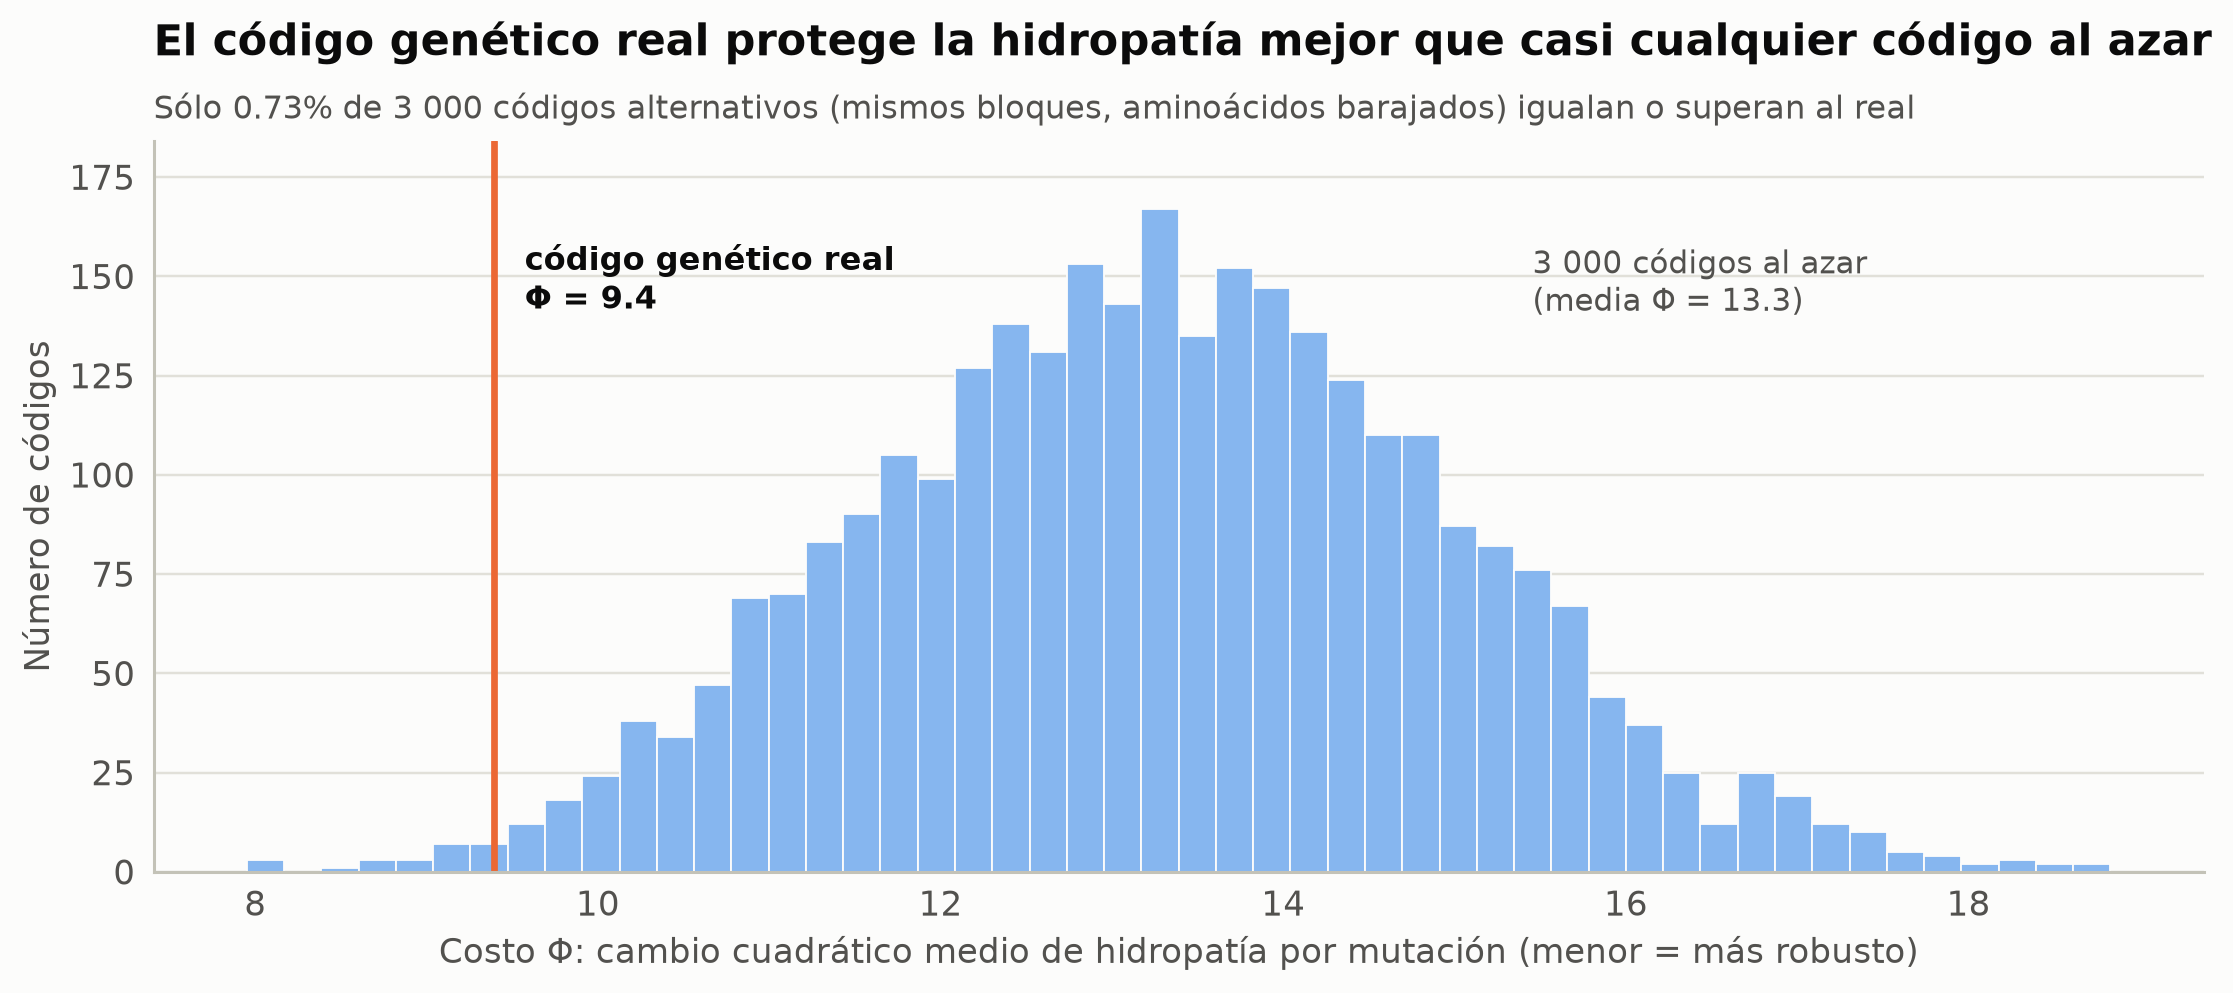

In [22]:
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.hist(random_costs, bins=50, color=ec.SEQ_BLUE[3], edgecolor=ec.SURFACE, linewidth=0.6)
ax.axvline(standard_cost, color=ec.ORANGE, lw=2.2)
ymax = ax.get_ylim()[1]
ax.annotate(f"código genético real\nΦ = {standard_cost:.1f}", xy=(standard_cost, ymax * 0.85),
            xytext=(10, 0), textcoords="offset points", ha="left", va="center", fontsize=10.5, color=ec.INK,
            fontweight="bold")
ax.text(np.percentile(random_costs, 90), ymax * 0.9, f"3 000 códigos al azar\n(media Φ = {random_costs.mean():.1f})",
        ha="left", va="top", fontsize=10, color=ec.INK_2)
ax.set_xlabel("Costo Φ: cambio cuadrático medio de hidropatía por mutación (menor = más robusto)")
ax.set_ylabel("Número de códigos")
ax.set_ylim(0, ymax * 1.05)
ec.title(ax, "El código genético real protege la hidropatía mejor que casi cualquier código al azar",
         f"Sólo {better:.2%} de 3 000 códigos alternativos (mismos bloques, aminoácidos barajados) igualan o superan al real")
plt.show()

> 🔎 **Qué observamos.** El código real (línea naranja) está en el **extremo izquierdo** de la distribución: casi
> ningún código generado al azar minimiza tan bien el daño de las mutaciones. Freeland y Hurst, usando una medida
> más refinada (el "requerimiento polar" de los aminoácidos) y ponderando los tipos de error, estimaron que sólo
> **uno en un millón** de códigos alternativos es mejor. El código genético no es un "accidente congelado"
> cualquiera: está organizado de forma que tolera errores.

> ✅ **Compruebe su comprensión.**
> 1. ¿Por qué excluimos los codones de parada al barajar los aminoácidos?
> 2. Si el código estuviera optimizado para la **carga** de los aminoácidos en lugar de la hidropatía, ¿cómo
>    modificaría el experimento?

## ✍️ Ejercicios

**Ejercicio 1 — Entropía y expansión de repeticiones.** Tome la repetición `CAG × 40` e introduzca una mutación
cada 10 codones (por ejemplo `CAG` → `CAA`, que sigue siendo glutamina). ¿Cómo cambian la entropía con $k=1$ y
$k=3$? ¿Qué cambiaría en la proteína?

**Ejercicio 2 — Transiciones y transversiones.** Las **transiciones** (A↔G, C↔T) son unas dos veces más frecuentes
que las **transversiones** en la naturaleza. Usando la tabla `muts`, calcule el porcentaje de mutaciones sinónimas en
la 3ª posición separando transiciones y transversiones. ¿Cuál es más "silenciosa"?

**Ejercicio 3 — La proteína como texto.** Calcule la entropía de Shannon ($k=1$) de la proteína Spike sobre el
alfabeto de 20 aminoácidos y compárela con el máximo $\log_2 20$. ¿Es la composición de aminoácidos cercana a
uniforme?

**Ejercicio 4 — Bytes de su organismo favorito.** Elija un organismo, busque el tamaño de su genoma en el NCBI
(*Genome*) y calcule cuánto ocupa a 2 bits por base y en FASTA sin comprimir.

In [23]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
pure = "CAG" * 40
mutated = "".join("CAA" if i % 10 == 9 else "CAG" for i in range(40))
for name, s in [("CAG×40 pura", pure), ("CAG×40 con CAA cada 10", mutated)]:
    print(f"{name:26s} H(k=1) = {shannon_entropy(s):.3f} · H(k=3)/3 = {shannon_entropy(s, 3) / 3:.3f} · "
          f"proteína = {translate(transcribe(s))[:12]}…")
print("La proteína no cambia (CAA y CAG son Gln), pero la entropía sube: la secuencia es menos repetitiva.")

CAG×40 pura                H(k=1) = 1.585 · H(k=3)/3 = 0.528 · proteína = QQQQQQQQQQQQ…
CAG×40 con CAA cada 10     H(k=1) = 1.580 · H(k=3)/3 = 0.667 · proteína = QQQQQQQQQQQQ…
La proteína no cambia (CAA y CAG son Gln), pero la entropía sube: la secuencia es menos repetitiva.


In [24]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
TRANSITIONS = {("A", "G"), ("G", "A"), ("C", "T"), ("T", "C")}
third = muts[muts["position"] == 3].copy()
third["tipo"] = [("transición" if (c[2], m[2]) in TRANSITIONS else "transversión")
                 for c, m in zip(third["codon"], third["mutant"])]
print(pd.crosstab(third["tipo"], third["effect"], normalize="index").mul(100).round(1))

effect        missense  sinónima  terminadora
tipo                                         
transición         2.5      96.5          0.9
transversión      46.3      47.8          5.8


In [25]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
H_prot = shannon_entropy(official)
print(f"H(Spike) = {H_prot:.3f} bits por aminoácido · máximo log2(20) = {np.log2(20):.3f}")
print("Está cerca del máximo pero no lo alcanza: algunos aminoácidos (L, S, T, V) son mucho más frecuentes que otros (W, M, H).")

H(Spike) = 4.159 bits por aminoácido · máximo log2(20) = 4.322
Está cerca del máximo pero no lo alcanza: algunos aminoácidos (L, S, T, V) son mucho más frecuentes que otros (W, M, H).


## 📌 Resumen

* El **dogma central** describe un sistema de información: el ADN **guarda**, el ARN es la **copia de trabajo** y
  la proteína **ejecuta**. La información no fluye de proteína a ácido nucleico; los virus añaden transcripción
  reversa y replicación de ARN.
* **Transcribir** es cambiar T por U en la hebra codificante; **traducir** es aplicar el diccionario de 64 codones.
  Nuestra implementación reprodujo exactamente la proteína Spike del NCBI.
* Una base contiene como máximo $\log_2 4 = 2$ bits; un genoma humano ≈ 775 MB a 2 bits por base.
* La **entropía de Shannon** $H = -\sum p \log_2 p$ mide la sorpresa promedio: 0 bits en una secuencia de una sola
  letra, 2 bits en una aleatoria. Los genomas reales están cerca de 2; las repeticiones, muy por debajo.
* La **compresión** es una medida empírica de información: los compresores genéricos no bajan de ~2 bits con ADN
  real, pero comprimen muchísimo las repeticiones.
* El código genético es **robusto**: la 3ª posición del codón absorbe la mayoría de las mutaciones (*wobble*), y la
  organización del código minimiza el daño fisicoquímico mejor que casi cualquier código alternativo.

**Próxima lección (1.2):** genes, genomas y marcos abiertos de lectura — construiremos un buscador de genes y lo
probaremos en un genoma bacteriano completo.

## 📚 Para profundizar

* Crick, F. (1970). Central dogma of molecular biology. *Nature* 227: 561–563.
* Shannon, C. E. (1948). A mathematical theory of communication. *Bell System Technical Journal* 27: 379–423.
* Freeland, S. J. & Hurst, L. D. (1998). The genetic code is one in a million. *Journal of Molecular Evolution*
  47: 238–248.
* Kyte, J. & Doolittle, R. F. (1982). A simple method for displaying the hydropathic character of a protein.
  *Journal of Molecular Biology* 157: 105–132.
* Alberts, B. *et al.* *Molecular Biology of the Cell* (Garland Science), capítulos 6 y 7.

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)